# COMP90049 Assignment 2 — Bank Marketing

## Dataset

This project uses the **Bank Marketing dataset** from the **UCI Machine Learning Repository**.

The data is related to direct marketing campaigns conducted by a Portuguese banking institution through phone calls. The prediction target is whether a client subscribes to a term deposit (`y`).

- Dataset: Bank Marketing
- Source: UCI Machine Learning Repository
- File used: `bank-additional-full.csv`
- Instances before cleaning: 41,188
- Target: `y`
  - `yes` = subscribed to a term deposit
  - `no` = did not subscribe

## Research Questions

### RQ1
**How effectively can different machine learning models predict whether a client will subscribe to a term deposit?**

RQ1 uses a broader feature set including demographic, financial, current campaign, previous campaign, and socio-economic information.

The `duration` feature is excluded because it is only known after the phone call has ended.

### RQ2
**How much does previous campaign history contribute to subscription prediction beyond customer demographic and financial information?**

RQ2 compares two feature sets:

- **Set A:** Customer demographic and financial information only.
- **Set B:** Set A plus previous campaign history.

The difference in predictive performance between Set A and Set B is used to estimate the additional predictive value of previous campaign history.

## Experimental Setup

- Exact duplicate rows are removed.
- The target is encoded as:
  - `no = 0`
  - `yes = 1`
- An 80/20 stratified train/test split is used.
- RQ1, RQ2 Set A, and RQ2 Set B use the same train/test observations.
- Categorical features are one-hot encoded.
- Numerical features are standardised.
- Preprocessing is fitted only on the training data to avoid data leakage.

## Reading Guide

Sections 15–17 contain the primary neural-network experiments and conclusions,
using ordinary gradient descent and backpropagation. The earlier Adam experiments
in Sections 11–13 are retained as supplementary work; Adam is not confirmed in
the supplied course material and is not part of the course-scope claim.
ROC-AUC is supplementary; the primary comparison uses accuracy, precision, recall
and F1. Tables explicitly distinguish the two MLP versions.

## Team Workflow

- **Person A:** Data preparation, preprocessing, literature review, and RQ2 analysis.
- **Person B:** Classical ML models, hyperparameter tuning, evaluation, and RQ1 lead.
- **Person C:** Neural network modelling, evaluation, bibliography, and report integration.

In [93]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 9.5/9.5 MB 55.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 48.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------- 7.2/7.2 MB 63.9 MB/s  0:00:00

   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----- ---------------------------------- 1/7 [pillow]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3/7 [fonttools]
   ----------------- ---------------------- 3

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## 1. Load Data

In [31]:
import pandas as pd

# Load the full Bank Marketing dataset
df = pd.read_csv("data/bank-additional-full.csv", sep=";")

# Preview the first five rows
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 2. Basic Data Inspection

In [32]:
# Check dataset dimensions
print("Shape:", df.shape)

# Display all column names
print("\nColumns:")
print(df.columns.tolist())

Shape: (41188, 21)

Columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


In [33]:
# Inspect data types and non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [34]:
# Check target class counts
print("Target counts:")
print(df["y"].value_counts())

# Check target class proportions
print("\nTarget proportions:")
print(df["y"].value_counts(normalize=True))

Target counts:
y
no     36548
yes     4640
Name: count, dtype: int64

Target proportions:
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


## 3. Data Quality Analysis

In [35]:
# Count standard missing values in each column
missing_counts = df.isnull().sum()

missing_counts

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [36]:
# Count "unknown" categorical values in each column
unknown_counts = (df == "unknown").sum()

# Show only columns containing unknown values
unknown_counts[unknown_counts > 0]

job           330
marital        80
education    1731
default      8597
housing       990
loan          990
dtype: int64

In [37]:
# Calculate percentage of unknown values
unknown_percent = unknown_counts[unknown_counts > 0] / len(df) * 100

unknown_percent.round(2)

job           0.80
marital       0.19
education     4.20
default      20.87
housing       2.40
loan          2.40
dtype: float64

In [38]:
# Summarise class distribution
class_distribution = pd.DataFrame({
    "count": df["y"].value_counts(),
    "percentage": df["y"].value_counts(normalize=True) * 100
})

class_distribution.round(2)

,count,percentage
y,,
no,36548,88.73
yes,4640,11.27


In [39]:
# Count exact duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 12


In [40]:
# Distribution of previous campaign contacts
df["previous"].value_counts().sort_index()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

In [41]:
# Distribution of previous campaign outcomes
df["poutcome"].value_counts()

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [42]:
# Compare previous contact counts with previous campaign outcomes
pd.crosstab(df["previous"], df["poutcome"])

poutcome,failure,nonexistent,success
previous,,,
0,0,35563,0
1,3696,0,865
2,434,0,320
3,88,0,128
4,30,0,40
5,3,0,15
6,1,0,4
7,0,0,1


In [43]:
# Inspect pdays values
df["pdays"].value_counts().sort_index()

pdays
0         15
1         26
2         61
3        439
4        118
5         46
6        412
7         60
8         18
9         64
10        52
11        28
12        58
13        36
14        20
15        24
16        11
17         8
18         7
19         3
20         1
21         2
22         3
25         1
26         1
27         1
999    39673
Name: count, dtype: int64

In [44]:
# Count records using the special pdays value 999
pdays_999_count = (df["pdays"] == 999).sum()

print("Number of pdays = 999:", pdays_999_count)
print("Percentage:", round(pdays_999_count / len(df) * 100, 2), "%")

Number of pdays = 999: 39673
Percentage: 96.32 %


In [45]:
# Previous contacts exist, but pdays is still 999
previous_with_999 = (
    (df["previous"] > 0) &
    (df["pdays"] == 999)
).sum()

print("Previous > 0 and pdays = 999:", previous_with_999)

Previous > 0 and pdays = 999: 4110


In [46]:
# No previous contacts, but pdays has a recorded value
no_previous_with_pdays = (
    (df["previous"] == 0) &
    (df["pdays"] != 999)
).sum()

print("Previous = 0 and pdays != 999:", no_previous_with_pdays)

Previous = 0 and pdays != 999: 0


In [47]:
# Compare previous campaign outcome with current subscription outcome
poutcome_target = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
)

poutcome_target

y,no,yes
poutcome,,
failure,0.857714,0.142286
nonexistent,0.911678,0.088322
success,0.348871,0.651129


## 4. Remove Duplicate Rows

In [48]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Confirm the updated dataset size
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (41176, 21)


In [49]:
# Confirm no duplicate rows remain
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


## 5 Define RQ1 Feature Set

RQ1 uses a broader feature set to compare the predictive performance of different machine learning models.

The `duration` feature is excluded because it is only known after the call has ended. The original `pdays` variable is replaced by the engineered `pdays_recorded` and `pdays_clean` features.

In [50]:
# Mark whether pdays contains an actual day value
df["pdays_recorded"] = (df["pdays"] != 999).astype(int)

# Replace the sentinel value 999 with 0
df["pdays_clean"] = df["pdays"].where(df["pdays"] != 999, 0)

In [51]:
# Full feature set for RQ1 model comparison
rq1_features = [
    # Demographic and financial
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",

    # Current campaign
    "contact",
    "month",
    "day_of_week",
    "campaign",

    # Previous campaign history
    "previous",
    "poutcome",
    "pdays_recorded",
    "pdays_clean",

    # Socio-economic context
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

# Create RQ1 feature matrix
X_rq1 = df[rq1_features].copy()

print("RQ1 feature count:", len(rq1_features))
print("RQ1 shape:", X_rq1.shape)

RQ1 feature count: 20
RQ1 shape: (41176, 20)


## 6. Define RQ2 Feature Groups

To address RQ2, two feature sets are defined:

- **Set A:** Customer demographic and financial information only.
- **Set B:** Set A plus previous campaign history.

The comparison between these two sets will be used to measure the additional predictive value of previous campaign history.

In [52]:
# Demographic and financial features
base_features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

print("Base features:")
print(base_features)

Base features:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']


In [53]:
# Previous campaign history features
history_features = [
    "previous",
    "poutcome",
    "pdays_recorded",
    "pdays_clean"
]

print("History features:")
print(history_features)

History features:
['previous', 'poutcome', 'pdays_recorded', 'pdays_clean']


In [54]:
# Set A: demographic + financial information
features_without_history = base_features

# Set B: base features + previous campaign history
features_with_history = base_features + history_features

print("Set A - Without history:")
print(features_without_history)

print("\nSet B - With history:")
print(features_with_history)

Set A - Without history:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

Set B - With history:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'previous', 'poutcome', 'pdays_recorded', 'pdays_clean']


In [55]:
# Create the two RQ2 feature matrices
X_without_history = df[features_without_history].copy()
X_with_history = df[features_with_history].copy()

# Encode target: no = 0, yes = 1
y = df["y"].map({"no": 0, "yes": 1})

print("Set A shape:", X_without_history.shape)
print("Set B shape:", X_with_history.shape)
print("Target shape:", y.shape)

Set A shape: (41176, 7)
Set B shape: (41176, 11)
Target shape: (41176,)


In [56]:
# Check target encoding
y.value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

In [57]:
# Preview both feature sets
print("Set A:")
display(X_without_history.head())

print("Set B:")
display(X_with_history.head())

Set A:


,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


Set B:


,age,job,marital,education,default,housing,loan,previous,poutcome,pdays_recorded,pdays_clean
0,56,housemaid,married,basic.4y,no,no,no,0,nonexistent,0,0
1,57,services,married,high.school,unknown,no,no,0,nonexistent,0,0
2,37,services,married,high.school,no,yes,no,0,nonexistent,0,0
3,40,admin.,married,basic.6y,no,no,no,0,nonexistent,0,0
4,56,services,married,high.school,no,no,yes,0,nonexistent,0,0


## 7. Train/Test Split

The data is split into 80% training and 20% test sets using stratified sampling to preserve the class distribution of the target variable.

The same train/test observations are used for RQ1 and both RQ2 feature sets to ensure consistent and fair model comparisons.

In [58]:
from sklearn.model_selection import train_test_split

# Split row indices once so both feature sets use identical samples
train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(train_idx))
print("Test samples:", len(test_idx))

Training samples: 32940
Test samples: 8236


In [59]:
# Set A: without previous campaign history
X_train_without = X_without_history.loc[train_idx].copy()
X_test_without = X_without_history.loc[test_idx].copy()

# Set B: with previous campaign history
X_train_with = X_with_history.loc[train_idx].copy()
X_test_with = X_with_history.loc[test_idx].copy()

# RQ1: full feature set
X_train_rq1 = X_rq1.loc[train_idx].copy()
X_test_rq1 = X_rq1.loc[test_idx].copy()

# Target
y_train = y.loc[train_idx].copy()
y_test = y.loc[test_idx].copy()

In [60]:
# Check train/test dimensions
print("RQ1 train:", X_train_rq1.shape)
print("RQ1 test:", X_test_rq1.shape)

print("\nSet A train:", X_train_without.shape)
print("Set A test:", X_test_without.shape)

print("\nSet B train:", X_train_with.shape)
print("Set B test:", X_test_with.shape)

print("\ny train:", y_train.shape)
print("y test:", y_test.shape)

RQ1 train: (32940, 20)
RQ1 test: (8236, 20)

Set A train: (32940, 7)
Set A test: (8236, 7)

Set B train: (32940, 11)
Set B test: (8236, 11)

y train: (32940,)
y test: (8236,)


In [61]:
# Check class proportions after splitting
print("Training target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTest target proportions:")
print(y_test.value_counts(normalize=True))

Training target proportions:
y
0    0.887341
1    0.112659
Name: proportion, dtype: float64

Test target proportions:
y
0    0.887324
1    0.112676
Name: proportion, dtype: float64


In [62]:
# Confirm all feature sets use the same rows
print(
    "RQ1 and Set A same training rows:",
    X_train_rq1.index.equals(X_train_without.index)
)

print(
    "RQ1 and Set B same training rows:",
    X_train_rq1.index.equals(X_train_with.index)
)

print(
    "RQ1 and Set A same test rows:",
    X_test_rq1.index.equals(X_test_without.index)
)

print(
    "RQ1 and Set B same test rows:",
    X_test_rq1.index.equals(X_test_with.index)
)

RQ1 and Set A same training rows: True
RQ1 and Set B same training rows: True
RQ1 and Set A same test rows: True
RQ1 and Set B same test rows: True


## 8. Preprocessing

Categorical features are one-hot encoded, while numerical features are standardised.

The `"unknown"` values are retained as valid categorical levels because removing these records would discard a substantial portion of the dataset.

All preprocessing transformations are fitted only on the training data and then applied to the test data to avoid data leakage.

In [63]:
# Set A categorical features
categorical_without = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan"
]

# Set A numerical features
numerical_without = [
    "age"
]

In [64]:
# Set B categorical features
categorical_with = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "poutcome"
]

# Set B numerical features
numerical_with = [
    "age",
    "previous",
    "pdays_clean"
]

# Binary indicator does not require scaling
binary_with = [
    "pdays_recorded"
]

In [65]:
# RQ1 categorical features
categorical_rq1 = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "day_of_week",
    "poutcome"
]

# RQ1 numerical features
numerical_rq1 = [
    "age",
    "campaign",
    "previous",
    "pdays_clean",
    "emp.var.rate",
    "cons.price.idx",
    "cons.conf.idx",
    "euribor3m",
    "nr.employed"
]

# RQ1 binary feature
binary_rq1 = [
    "pdays_recorded"
]

print(
    "RQ1 total raw features:",
    len(categorical_rq1) + len(numerical_rq1) + len(binary_rq1)
)

RQ1 total raw features: 20


In [66]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessor for Set A
preprocessor_without = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_without
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_without
        )
    ]
)

In [67]:
# Preprocessor for Set B
preprocessor_with = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_with
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_with
        ),
        (
            "binary",
            "passthrough",
            binary_with
        )
    ]
)

In [68]:
# Preprocessor for RQ1
preprocessor_rq1 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_rq1
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_rq1
        ),
        (
            "binary",
            "passthrough",
            binary_rq1
        )
    ]
)

In [69]:
# Fit preprocessing on Set A training data
X_train_without_processed = preprocessor_without.fit_transform(
    X_train_without
)

# Apply the same preprocessing to Set A test data
X_test_without_processed = preprocessor_without.transform(
    X_test_without
)

In [70]:
# Fit preprocessing on Set B training data
X_train_with_processed = preprocessor_with.fit_transform(
    X_train_with
)

# Apply the same preprocessing to Set B test data
X_test_with_processed = preprocessor_with.transform(
    X_test_with
)

In [71]:
# Fit preprocessing on RQ1 training data
X_train_rq1_processed = preprocessor_rq1.fit_transform(
    X_train_rq1
)

# Apply the same preprocessing to RQ1 test data
X_test_rq1_processed = preprocessor_rq1.transform(
    X_test_rq1
)

In [72]:
# Check processed dimensions
print("RQ1 train:", X_train_rq1_processed.shape)
print("RQ1 test:", X_test_rq1_processed.shape)

print("\nSet A train:", X_train_without_processed.shape)
print("Set A test:", X_test_without_processed.shape)

print("\nSet B train:", X_train_with_processed.shape)
print("Set B test:", X_test_with_processed.shape)

RQ1 train: (32940, 63)
RQ1 test: (8236, 63)

Set A train: (32940, 34)
Set A test: (8236, 34)

Set B train: (32940, 40)
Set B test: (8236, 40)


In [73]:
# Get processed feature names
feature_names_rq1 = preprocessor_rq1.get_feature_names_out()
feature_names_without = preprocessor_without.get_feature_names_out()
feature_names_with = preprocessor_with.get_feature_names_out()

print("RQ1 feature count:", len(feature_names_rq1))
print(feature_names_rq1)

print("\nSet A feature count:", len(feature_names_without))
print(feature_names_without)

print("\nSet B feature count:", len(feature_names_with))
print(feature_names_with)

RQ1 feature count: 63
['categorical__job_admin.' 'categorical__job_blue-collar'
 'categorical__job_entrepreneur' 'categorical__job_housemaid'
 'categorical__job_management' 'categorical__job_retired'
 'categorical__job_self-employed' 'categorical__job_services'
 'categorical__job_student' 'categorical__job_technician'
 'categorical__job_unemployed' 'categorical__job_unknown'
 'categorical__marital_divorced' 'categorical__marital_married'
 'categorical__marital_single' 'categorical__marital_unknown'
 'categorical__education_basic.4y' 'categorical__education_basic.6y'
 'categorical__education_basic.9y' 'categorical__education_high.school'
 'categorical__education_illiterate'
 'categorical__education_professional.course'
 'categorical__education_university.degree'
 'categorical__education_unknown' 'categorical__default_no'
 'categorical__default_unknown' 'categorical__default_yes'
 'categorical__housing_no' 'categorical__housing_unknown'
 'categorical__housing_yes' 'categorical__loan_no'


In [74]:
# Convert processed RQ1 data to DataFrames
X_train_rq1_processed = pd.DataFrame(
    X_train_rq1_processed,
    columns=feature_names_rq1,
    index=X_train_rq1.index
)

X_test_rq1_processed = pd.DataFrame(
    X_test_rq1_processed,
    columns=feature_names_rq1,
    index=X_test_rq1.index
)

# Convert processed Set A to DataFrames
X_train_without_processed = pd.DataFrame(
    X_train_without_processed,
    columns=feature_names_without,
    index=X_train_without.index
)

X_test_without_processed = pd.DataFrame(
    X_test_without_processed,
    columns=feature_names_without,
    index=X_test_without.index
)

# Convert processed Set B to DataFrames
X_train_with_processed = pd.DataFrame(
    X_train_with_processed,
    columns=feature_names_with,
    index=X_train_with.index
)

X_test_with_processed = pd.DataFrame(
    X_test_with_processed,
    columns=feature_names_with,
    index=X_test_with.index
)

In [75]:
# Final preprocessing checks
print("RQ1 missing values:",
      X_train_rq1_processed.isnull().sum().sum())

print("Set A missing values:",
      X_train_without_processed.isnull().sum().sum())

print("Set B missing values:",
      X_train_with_processed.isnull().sum().sum())

print(
    "RQ1 train rows match target:",
    X_train_rq1_processed.index.equals(y_train.index)
)

print(
    "RQ1 test rows match target:",
    X_test_rq1_processed.index.equals(y_test.index)
)

print(
    "Set A and Set B same training rows:",
    X_train_without_processed.index.equals(
        X_train_with_processed.index
    )
)

print(
    "Set A and Set B same test rows:",
    X_test_without_processed.index.equals(
        X_test_with_processed.index
    )
)

RQ1 missing values: 0
Set A missing values: 0
Set B missing values: 0
RQ1 train rows match target: True
RQ1 test rows match target: True
Set A and Set B same training rows: True
Set A and Set B same test rows: True


## 9. RQ2 Experimental Setup

RQ2 compares Set A (demographic/financial features) with Set B (Set A plus previous
campaign history), using identical observations, validation folds and metrics.
Classical models are tuned separately within each feature set using the same
candidate grid. Each MLP version instead holds its RQ1-selected configuration
fixed across A and B. The former compares separately tuned pipelines; the latter
compares added history under fixed training settings. Neither establishes causality.

In [76]:
# Summary of the two RQ2 feature sets
rq2_feature_sets = {
    "Set A - Without History": {
        "raw_features": features_without_history,
        "processed_feature_count": len(feature_names_without)
    },
    "Set B - With History": {
        "raw_features": features_with_history,
        "processed_feature_count": len(feature_names_with)
    }
}

for name, info in rq2_feature_sets.items():
    print(name)
    print("Raw features:", info["raw_features"])
    print("Processed feature count:", info["processed_feature_count"])
    print()

Set A - Without History
Raw features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
Processed feature count: 34

Set B - With History
Raw features: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'previous', 'poutcome', 'pdays_recorded', 'pdays_clean']
Processed feature count: 40



In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Evaluate a binary classification model
def evaluate_model(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [78]:
# Store RQ2 model comparison results
rq2_results = pd.DataFrame(
    columns=[
        "Model",
        "Feature Set",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC-AUC"
    ]
)

rq2_results

,Model,Feature Set,Accuracy,Precision,Recall,F1,ROC-AUC


## 10. Evaluation Protocol and Baseline

All models are evaluated using the same data partitions and metrics. The existing
stratified 80% training / 20% test split is retained. Hyperparameters are selected
using five-fold stratified cross-validation within the training set. Five folds
balance computational cost and repeated validation, while stratification preserves
the class proportions in each fold.

| Component | Specification |
| --- | --- |
| Target | Subscription: `yes = 1` (positive), `no = 0` (negative) |
| Train/test split | Stratified 80% / 20%, random seed 42 |
| Validation | Five-fold stratified cross-validation, random seed 42 |
| Model selection | Highest mean validation F1 for the positive class |
| Additional metrics | Accuracy, positive-class Precision and Recall; supplementary ROC-AUC |
| Prediction rule | Default model predictions; no threshold tuning |
| Preprocessing | Encoding and scaling fitted within each training fold |
| Baseline | Zero-R majority-class classifier |

The same validation folds are used across models and feature sets. After
hyperparameter selection, each selected pipeline will be refitted on the full
training set and evaluated on the held-out test set. Test results will not be
used to select hyperparameters.

ROC-AUC is reported as a supplementary measure of ranking performance using
probabilities or decision scores. It is not used for model selection.
The random split assesses generalisation to held-out observations from the
historical dataset, rather than to future campaigns.

### 10.1 Evaluation Metrics

Subscriptions account for approximately 11.27% of observations. A classifier that
always predicts `no` can therefore achieve approximately 88.73% accuracy without
identifying any subscribers. Positive-class F1 is the primary metric because it
combines precision and recall with equal emphasis.

- **Precision:** the proportion of predicted subscribers who actually subscribe.
- **Recall:** the proportion of actual subscribers correctly identified.
- **F1:** the harmonic mean of positive-class precision and recall.

$$F_1 = \frac{2PR}{P+R} = \frac{2TP}{2TP+FP+FN}$$

Binary F1 is calculated with `pos_label=1`. Accuracy, precision, recall and ROC-AUC
provide complementary descriptions of model performance. Exact ties in mean
validation F1 will be resolved using a predefined candidate order favouring
simpler configurations.

When no positive predictions are made, precision is undefined and is reported
as 0 using `zero_division=0`. The same convention is applied to all models.


In [79]:
import sys
import numpy as np
import sklearn
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, confusion_matrix

RANDOM_STATE = 42
N_SPLITS = 5
PRIMARY_METRIC = "f1"

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label=1, zero_division=0),
    "recall": make_scorer(recall_score, pos_label=1, zero_division=0),
    "f1": make_scorer(f1_score, pos_label=1, zero_division=0),
    "roc_auc": "roc_auc"
}

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.14.8
NumPy: 2.5.3
pandas: 3.0.6
scikit-learn: 1.9.1


In [80]:
# CV indices below are positional indices within the existing training data.
# Use .iloc (not .loc) if applying them manually.
for X_current in (X_train_rq1, X_train_without, X_train_with):
    assert X_current.index.equals(y_train.index)
assert X_train_rq1.index.intersection(X_test_rq1.index).empty

cv = StratifiedKFold(
    n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE
)
cv_splits = list(cv.split(X_train_rq1, y_train))

fold_rows = []
for fold, (fit_pos, val_pos) in enumerate(cv_splits, start=1):
    fold_rows.append({
        "Fold": fold,
        "Training samples": len(fit_pos),
        "Validation samples": len(val_pos),
        "Training yes proportion": y_train.iloc[fit_pos].mean(),
        "Validation yes proportion": y_train.iloc[val_pos].mean()
    })

fold_summary = pd.DataFrame(fold_rows)
display(fold_summary)

,Fold,Training samples,Validation samples,Training yes proportion,Validation yes proportion
0,1,26352,6588,0.112667,0.112629
1,2,26352,6588,0.112667,0.112629
2,3,26352,6588,0.112667,0.112629
3,4,26352,6588,0.112667,0.112629
4,5,26352,6588,0.112629,0.112781


### 10.2 Preprocessing Within Cross-Validation

Each model pipeline receives the raw training features and an unfitted copy of
the corresponding preprocessor. One-hot encoding and standardisation are fitted
on each fold's training observations and then applied to its validation observations.
This prevents validation data from influencing preprocessing.

The matrices previously transformed using the full training set are not used
as inputs to cross-validation. Separate preprocessors are used for the RQ1
feature set and the two RQ2 feature sets.

In [81]:
def make_model_pipeline(preprocessor, model):
    return Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", clone(model))
    ])

metric_names = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    "f1": "F1",
    "roc_auc": "ROC-AUC"
}

def summarise_cv(cv_output):
    """Summarise validation-fold metrics, using population variance (ddof=0)."""
    rows = []
    for key, name in metric_names.items():
        scores = np.asarray(cv_output["test_" + key])
        rows.append({
            "Metric": name,
            "CV mean": scores.mean(),
            "CV variance": scores.var(ddof=0),
            "CV SD": scores.std(ddof=0)
        })
    return pd.DataFrame(rows).set_index("Metric")

### 10.3 Zero-R Baseline

Zero-R predicts the most frequent class in the training data for every observation.
It is implemented using `DummyClassifier(strategy="most_frequent")`. The majority
class is determined independently within each training fold and is `no = 0`
in all five folds.

The baseline does not use feature values and requires no encoding or scaling.
Its validation results are identical for RQ1 and both RQ2 feature sets because
they share the same labels and fold assignments. The baseline is therefore
evaluated once as a common reference.


In [82]:
baseline = DummyClassifier(strategy="most_frequent")

baseline_cv = cross_validate(
    baseline,
    X_train_rq1,
    y_train,
    cv=cv_splits,
    scoring=scoring,
    return_estimator=True,
    n_jobs=1,
    error_score="raise"
)

baseline_fold_results = pd.DataFrame({
    name: baseline_cv["test_" + key]
    for key, name in metric_names.items()
})
baseline_fold_results.index = np.arange(1, N_SPLITS + 1)
baseline_fold_results.index.name = "Fold"

baseline_summary = summarise_cv(baseline_cv)
display(baseline_fold_results)
display(baseline_summary)

,Accuracy,Precision,Recall,F1,ROC-AUC
Fold,,,,,
1,0.887371,0.0,0.0,0.0,0.5
2,0.887371,0.0,0.0,0.0,0.5
3,0.887371,0.0,0.0,0.0,0.5
4,0.887371,0.0,0.0,0.0,0.5
5,0.887219,0.0,0.0,0.0,0.5


,CV mean,CV variance,CV SD
Metric,,,
Accuracy,0.887341,3.686488e-09,0.000061
Precision,0.000000,0.000000e+00,0.000000
Recall,0.000000,0.000000e+00,0.000000
F1,0.000000,0.000000e+00,0.000000
ROC-AUC,0.500000,0.000000e+00,0.000000


In [83]:
# Reuse the fitted fold models; each observation is predicted by a model
# trained without that observation. This is a validation confusion matrix.
baseline_oof_pred = np.empty(len(y_train), dtype=int)
for fitted_baseline, (_, val_pos) in zip(baseline_cv["estimator"], cv_splits):
    baseline_oof_pred[val_pos] = fitted_baseline.predict(
        X_train_rq1.iloc[val_pos]
    )

baseline_oof_cm = pd.DataFrame(
    confusion_matrix(y_train, baseline_oof_pred, labels=[0, 1]),
    index=["Actual no (0)", "Actual yes (1)"],
    columns=["Predicted no (0)", "Predicted yes (1)"]
)
display(baseline_oof_cm)
print("Zero-R mean validation accuracy:",
      f"{baseline_summary.loc['Accuracy', 'CV mean']:.2%}")
print("Zero-R mean validation F1:",
      f"{baseline_summary.loc['F1', 'CV mean']:.4f}")

,Predicted no (0),Predicted yes (1)
Actual no (0),29229,0
Actual yes (1),3711,0


Zero-R mean validation accuracy: 88.73%
Zero-R mean validation F1: 0.0000


### 10.4 Baseline Results and Interpretation

Zero-R achieves **88.73% mean validation accuracy**, while positive-class
precision, recall and F1 are all **0**. Its constant probability score yields
**ROC-AUC = 0.5**. Across the out-of-fold predictions, all 29,229 non-subscribers
are classified correctly and all 3,711 subscribers are missed. This demonstrates
why accuracy alone is insufficient for this imbalanced task.

The confusion matrix aggregates validation predictions over the 32,940 training
observations; each prediction comes from a model trained without that observation.
These are cross-validation results, not held-out test results. Fold means,
variances and standard deviations describe variation across the five validation
folds; they are not confidence intervals.

Subsequent models will be compared with this baseline under the same evaluation
protocol. Exceeding Zero-R's F1 is a minimum reference rather than sufficient
evidence of practical usefulness. For RQ2, classical models use the same search grid but may select different
parameters for A and B. Each MLP comparison fixes its own selected training settings
across the two feature sets.

### 10.5 Reproducibility and Sources

Obtain `bank-additional-full.csv` from the
[UCI Bank Marketing dataset](https://archive.ics.uci.edu/dataset/222/bank+marketing)
and place it at `data/bank-additional-full.csv` relative to this notebook.
Restart the kernel and run all cells in order. Software versions are recorded
above; the raw data is not embedded in this notebook.

Implementation references:
[scikit-learn DummyClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html)
and [scikit-learn cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html).

### RQ1: Logistic Regression

In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

# Candidate C values
C_values = [0.01, 0.1, 1, 10, 100, 1000]

lr_rows = []

best_lr_C = None
best_lr_f1 = -1
best_lr_cv = None

for C in C_values:
    
    # Create Logistic Regression model
    lr = LogisticRegression(
        C=C,
        max_iter=2000
    )
    
    # Put preprocessing and model in the same pipeline
    lr_pipeline = make_model_pipeline(
        preprocessor_rq1,
        lr
    )
    
    # 5-fold cross-validation on training data
    cv_result = cross_validate(
        lr_pipeline,
        X_train_rq1,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=1
    )
    
    # Calculate mean and SD of validation F1
    mean_f1 = cv_result["test_f1"].mean()
    sd_f1 = cv_result["test_f1"].std()
    
    lr_rows.append({
        "C": C,
        "Mean CV F1": mean_f1,
        "CV F1 SD": sd_f1
    })
    
    # Keep the C value with the highest mean CV F1
    if mean_f1 > best_lr_f1:
        best_lr_f1 = mean_f1
        best_lr_C = C
        best_lr_cv = cv_result


# Show tuning results
lr_tuning_results = pd.DataFrame(lr_rows)

display(lr_tuning_results)

print("Best C:", best_lr_C)
print("Best mean CV F1:", round(best_lr_f1, 4))

# Create final Logistic Regression using the best C
best_lr = LogisticRegression(
    C=best_lr_C,
    max_iter=2000
)

best_lr_pipeline = make_model_pipeline(
    preprocessor_rq1,
    best_lr
)

# Train on the entire training set
best_lr_pipeline.fit(
    X_train_rq1,
    y_train
)

# Predict the test set
lr_test_pred = best_lr_pipeline.predict(
    X_test_rq1
)

lr_test_prob = best_lr_pipeline.predict_proba(
    X_test_rq1
)[:, 1]

# Evaluate test performance
lr_test_metrics = evaluate_model(
    y_test,
    lr_test_pred,
    lr_test_prob
)

print("Logistic Regression test results:")
print(lr_test_metrics)

,C,Mean CV F1,CV F1 SD
0,0.01,0.310511,0.008168
1,0.10,0.336992,0.007883
2,1.00,0.342670,0.004887
3,10.00,0.343436,0.004704
4,100.00,0.344698,0.004927
5,1000.00,0.343789,0.004523


Best C: 100
Best mean CV F1: 0.3447
Logistic Regression test results:
{'Accuracy': 0.8983729966002914, 'Precision': 0.6491803278688525, 'Recall': 0.21336206896551724, 'F1': 0.32116788321167883, 'ROC-AUC': 0.8003312235764302}


### RQ1: Decision Tree

In [85]:
from sklearn.tree import DecisionTreeClassifier

# Candidate maximum depths
max_depth_values = [1, 5, 10, 15, 20, None]

dt_rows = []

best_dt_depth = None
best_dt_f1 = -1
best_dt_cv = None

for depth in max_depth_values:
    
    # Create Decision Tree
    dt = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=42
    )
    
    # Pipeline
    dt_pipeline = make_model_pipeline(
        preprocessor_rq1,
        dt
    )
    
    # Cross-validation
    cv_result = cross_validate(
        dt_pipeline,
        X_train_rq1,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=1
    )
    
    mean_f1 = cv_result["test_f1"].mean()
    sd_f1 = cv_result["test_f1"].std()
    
    dt_rows.append({
        "max_depth": str(depth),
        "Mean CV F1": mean_f1,
        "CV F1 SD": sd_f1
    })
    
    # Keep best depth
    if mean_f1 > best_dt_f1:
        best_dt_f1 = mean_f1
        best_dt_depth = depth
        best_dt_cv = cv_result


# Show tuning results
dt_tuning_results = pd.DataFrame(dt_rows)

display(dt_tuning_results)

print("Best max_depth:", best_dt_depth)
print("Best mean CV F1:", round(best_dt_f1, 4))

# Create final Decision Tree
best_dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=best_dt_depth,
    random_state=42
)

best_dt_pipeline = make_model_pipeline(
    preprocessor_rq1,
    best_dt
)

# Train using whole training set
best_dt_pipeline.fit(
    X_train_rq1,
    y_train
)

# Predict test data
dt_test_pred = best_dt_pipeline.predict(
    X_test_rq1
)

dt_test_prob = best_dt_pipeline.predict_proba(
    X_test_rq1
)[:, 1]

# Test metrics
dt_test_metrics = evaluate_model(
    y_test,
    dt_test_pred,
    dt_test_prob
)

print("Decision Tree test results:")
print(dt_test_metrics)

,max_depth,Mean CV F1,CV F1 SD
0,1,0.000000,0.000000
1,5,0.364769,0.027528
2,10,0.371587,0.014494
3,15,0.373457,0.015579
4,20,0.345345,0.011008
5,None,0.319253,0.014126


Best max_depth: 15
Best mean CV F1: 0.3735
Decision Tree test results:
{'Accuracy': 0.8902379796017484, 'Precision': 0.5234375, 'Recall': 0.28879310344827586, 'F1': 0.37222222222222223, 'ROC-AUC': 0.6868212003142516}


### RQ1: SVM

In [86]:
from sklearn.svm import SVC

# Candidate C values
C_values_svm = [0.01, 0.1, 1]

svm_rows = []

best_svm_C = None
best_svm_f1 = -1
best_svm_cv = None

for C in C_values_svm:
    
    # Linear SVM, consistent with tutorial
    svm = SVC(
        kernel="linear",
        C=C
    )
    
    # Pipeline
    svm_pipeline = make_model_pipeline(
        preprocessor_rq1,
        svm
    )
    
    # Cross-validation
    cv_result = cross_validate(
        svm_pipeline,
        X_train_rq1,
        y_train,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=1
    )
    
    mean_f1 = cv_result["test_f1"].mean()
    sd_f1 = cv_result["test_f1"].std()
    
    svm_rows.append({
        "C": C,
        "Mean CV F1": mean_f1,
        "CV F1 SD": sd_f1
    })
    
    # Keep best C
    if mean_f1 > best_svm_f1:
        best_svm_f1 = mean_f1
        best_svm_C = C
        best_svm_cv = cv_result


# Show tuning results
svm_tuning_results = pd.DataFrame(svm_rows)

display(svm_tuning_results)

print("Best C:", best_svm_C)
print("Best mean CV F1:", round(best_svm_f1, 4))

# Create final SVM
best_svm = SVC(
    kernel="linear",
    C=best_svm_C
)

best_svm_pipeline = make_model_pipeline(
    preprocessor_rq1,
    best_svm
)

# Train on whole training set
best_svm_pipeline.fit(
    X_train_rq1,
    y_train
)

# Predict test classes
svm_test_pred = best_svm_pipeline.predict(
    X_test_rq1
)

# Decision scores for ROC-AUC
svm_test_score = best_svm_pipeline.decision_function(
    X_test_rq1
)

# Test metrics
svm_test_metrics = evaluate_model(
    y_test,
    svm_test_pred,
    svm_test_score
)

print("SVM test results:")
print(svm_test_metrics)

,C,Mean CV F1,CV F1 SD
0,0.01,0.300523,0.009066
1,0.10,0.307540,0.011237
2,1.00,0.307540,0.011237


Best C: 0.1
Best mean CV F1: 0.3075
SVM test results:
{'Accuracy': 0.8952161243322001, 'Precision': 0.6164874551971327, 'Recall': 0.1853448275862069, 'F1': 0.28500414250207123, 'ROC-AUC': 0.7327025148396655}


### RQ1: Comparison of Three Classical Models

In [87]:
rq1_results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Best Hyperparameter": f"C = {best_lr_C}",
        "Mean CV F1": best_lr_f1,
        "Test Accuracy": lr_test_metrics["Accuracy"],
        "Test Precision": lr_test_metrics["Precision"],
        "Test Recall": lr_test_metrics["Recall"],
        "Test F1": lr_test_metrics["F1"],
        "Test ROC-AUC": lr_test_metrics["ROC-AUC"]
    },
    {
        "Model": "Decision Tree",
        "Best Hyperparameter": f"max_depth = {best_dt_depth}",
        "Mean CV F1": best_dt_f1,
        "Test Accuracy": dt_test_metrics["Accuracy"],
        "Test Precision": dt_test_metrics["Precision"],
        "Test Recall": dt_test_metrics["Recall"],
        "Test F1": dt_test_metrics["F1"],
        "Test ROC-AUC": dt_test_metrics["ROC-AUC"]
    },
    {
        "Model": "SVM",
        "Best Hyperparameter": f"C = {best_svm_C}",
        "Mean CV F1": best_svm_f1,
        "Test Accuracy": svm_test_metrics["Accuracy"],
        "Test Precision": svm_test_metrics["Precision"],
        "Test Recall": svm_test_metrics["Recall"],
        "Test F1": svm_test_metrics["F1"],
        "Test ROC-AUC": svm_test_metrics["ROC-AUC"]
    }
])

rq1_results = rq1_results.sort_values(
    by="Mean CV F1",
    ascending=False
).reset_index(drop=True)

display(rq1_results.round(4))

,Model,Best Hyperparameter,Mean CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Decision Tree,max_depth = 15,0.3735,0.8902,0.5234,0.2888,0.3722,0.6868
1,Logistic Regression,C = 100,0.3447,0.8984,0.6492,0.2134,0.3212,0.8003
2,SVM,C = 0.1,0.3075,0.8952,0.6165,0.1853,0.2850,0.7327


### RQ2

In [88]:
# Define the sets for RQ2
rq2_sets = {
    "Set A": {
        "X_train": X_train_without,
        "X_test": X_test_without,
        "preprocessor": preprocessor_without
    },
    "Set B": {
        "X_train": X_train_with,
        "X_test": X_test_with,
        "preprocessor": preprocessor_with
    }
}

### RQ2: Logistic Regression

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

C_values = [0.01, 0.1, 1, 10, 100, 1000]

lr_rq2_tuning = {}
lr_rq2_best = {}

for set_name, data in rq2_sets.items():

    rows = []

    best_C = None
    best_f1 = -1

    for C in C_values:

        lr = LogisticRegression(
            C=C,
            max_iter=2000
        )

        lr_pipeline = make_model_pipeline(
            data["preprocessor"],
            lr
        )

        cv_result = cross_validate(
            lr_pipeline,
            data["X_train"],
            y_train,
            cv=cv_splits,
            scoring=scoring,
            n_jobs=1,
            error_score="raise"
        )

        mean_f1 = cv_result["test_f1"].mean()
        sd_f1 = cv_result["test_f1"].std()

        rows.append({
            "C": C,
            "Mean CV F1": mean_f1,
            "CV F1 SD": sd_f1
        })

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_C = C

    # Save tuning table
    lr_rq2_tuning[set_name] = pd.DataFrame(rows)

    # Save best parameter
    lr_rq2_best[set_name] = {
        "C": best_C,
        "Mean CV F1": best_f1
    }

print("Logistic Regression - Set A")
display(lr_rq2_tuning["Set A"])

print(
    "Best C:",
    lr_rq2_best["Set A"]["C"]
)

print(
    "Best CV F1:",
    round(lr_rq2_best["Set A"]["Mean CV F1"], 4)
)


print("\nLogistic Regression - Set B")
display(lr_rq2_tuning["Set B"])

print(
    "Best C:",
    lr_rq2_best["Set B"]["C"]
)

print(
    "Best CV F1:",
    round(lr_rq2_best["Set B"]["Mean CV F1"], 4)
)

lr_rq2_results = []

for set_name, data in rq2_sets.items():

    best_C = lr_rq2_best[set_name]["C"]

    final_lr = LogisticRegression(
        C=best_C,
        max_iter=2000
    )

    final_pipeline = make_model_pipeline(
        data["preprocessor"],
        final_lr
    )

    # Train on the whole training set
    final_pipeline.fit(
        data["X_train"],
        y_train
    )

    # Test predictions
    y_pred = final_pipeline.predict(
        data["X_test"]
    )

    y_prob = final_pipeline.predict_proba(
        data["X_test"]
    )[:, 1]

    # Calculate test metrics
    rq2_metrics = evaluate_model(
        y_test,
        y_pred,
        y_prob
    )

    # Save result for this feature set
    lr_rq2_results.append({
        "Model": "Logistic Regression",
        "Feature Set": set_name,
        "Best Parameter": f"C = {best_C}",
        "Mean CV F1": lr_rq2_best[set_name]["Mean CV F1"],
        **rq2_metrics
    })


# Convert results to table
lr_rq2_results_df = pd.DataFrame(lr_rq2_results)

display(lr_rq2_results_df.round(4))

Logistic Regression - Set A


,C,Mean CV F1,CV F1 SD
0,0.01,0.0,0.0
1,0.10,0.0,0.0
2,1.00,0.0,0.0
3,10.00,0.0,0.0
4,100.00,0.0,0.0
5,1000.00,0.0,0.0


Best C: 0.01
Best CV F1: 0.0

Logistic Regression - Set B


,C,Mean CV F1,CV F1 SD
0,0.01,0.259391,0.016598
1,0.10,0.300427,0.010263
2,1.00,0.304438,0.010155
3,10.00,0.304445,0.010928
4,100.00,0.304800,0.010598
5,1000.00,0.304800,0.010598


Best C: 100
Best CV F1: 0.3048


,Model,Feature Set,Best Parameter,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Set A,C = 0.01,0.0000,0.8873,0.0000,0.0000,0.0000,0.6479
1,Logistic Regression,Set B,C = 100,0.3048,0.8956,0.6241,0.1843,0.2845,0.7014


### RQ2: Decision Tree

In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate

max_depth_values = [1, 5, 10, 15, 20, None]

dt_rq2_tuning = {}
dt_rq2_best = {}

for set_name, data in rq2_sets.items():

    rows = []

    best_depth = None
    best_f1 = -1

    for depth in max_depth_values:

        dt = DecisionTreeClassifier(
            criterion="entropy",
            max_depth=depth,
            random_state=42
        )

        dt_pipeline = make_model_pipeline(
            data["preprocessor"],
            dt
        )

        cv_result = cross_validate(
            dt_pipeline,
            data["X_train"],
            y_train,
            cv=cv_splits,
            scoring=scoring,
            n_jobs=1,
            error_score="raise"
        )

        mean_f1 = cv_result["test_f1"].mean()
        sd_f1 = cv_result["test_f1"].std()

        rows.append({
            "max_depth": str(depth),
            "Mean CV F1": mean_f1,
            "CV F1 SD": sd_f1
        })

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_depth = depth

    # Save tuning table
    dt_rq2_tuning[set_name] = pd.DataFrame(rows)

    # Save best parameter
    dt_rq2_best[set_name] = {
        "max_depth": best_depth,
        "Mean CV F1": best_f1
    }


# Display tuning results after both sets have finished
print("Decision Tree - Set A")
display(dt_rq2_tuning["Set A"])

print(
    "Best max_depth:",
    dt_rq2_best["Set A"]["max_depth"]
)

print(
    "Best CV F1:",
    round(dt_rq2_best["Set A"]["Mean CV F1"], 4)
)


print("\nDecision Tree - Set B")
display(dt_rq2_tuning["Set B"])

print(
    "Best max_depth:",
    dt_rq2_best["Set B"]["max_depth"]
)

print(
    "Best CV F1:",
    round(dt_rq2_best["Set B"]["Mean CV F1"], 4)
)

dt_rq2_results = []

for set_name, data in rq2_sets.items():

    best_depth = dt_rq2_best[set_name]["max_depth"]

    final_dt = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=best_depth,
        random_state=42
    )

    final_pipeline = make_model_pipeline(
        data["preprocessor"],
        final_dt
    )

    # Train on the whole training set
    final_pipeline.fit(
        data["X_train"],
        y_train
    )

    # Test predictions
    y_pred = final_pipeline.predict(
        data["X_test"]
    )

    y_prob = final_pipeline.predict_proba(
        data["X_test"]
    )[:, 1]

    # Calculate test metrics
    rq2_metrics = evaluate_model(
        y_test,
        y_pred,
        y_prob
    )

    # Save result for this feature set
    dt_rq2_results.append({
        "Model": "Decision Tree",
        "Feature Set": set_name,
        "Best Parameter": f"max_depth = {best_depth}",
        "Mean CV F1": dt_rq2_best[set_name]["Mean CV F1"],
        **rq2_metrics
    })


# Convert results to table
dt_rq2_results_df = pd.DataFrame(dt_rq2_results)

display(dt_rq2_results_df.round(4))

Decision Tree - Set A


,max_depth,Mean CV F1,CV F1 SD
0,1,0.000000,0.000000
1,5,0.047601,0.018928
2,10,0.071973,0.014726
3,15,0.125424,0.008136
4,20,0.133977,0.005927
5,None,0.140262,0.007906


Best max_depth: None
Best CV F1: 0.1403

Decision Tree - Set B


,max_depth,Mean CV F1,CV F1 SD
0,1,0.317154,0.009706
1,5,0.290023,0.012448
2,10,0.294960,0.014457
3,15,0.271566,0.012351
4,20,0.266038,0.010087
5,None,0.259794,0.008229


Best max_depth: 1
Best CV F1: 0.3172


,Model,Feature Set,Best Parameter,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,Set A,max_depth = None,0.1403,0.8628,0.2098,0.0787,0.1144,0.5829
1,Decision Tree,Set B,max_depth = 1,0.3172,0.8953,0.6071,0.2015,0.3026,0.5925


### RQ2: SVM

In [91]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate

C_values_svm = [0.1, 1]

svm_rq2_tuning = {}
svm_rq2_best = {}

for set_name, data in rq2_sets.items():

    rows = []

    best_C = None
    best_f1 = -1

    for C in C_values_svm:

        svm = SVC(
            kernel="linear",
            C=C
        )

        svm_pipeline = make_model_pipeline(
            data["preprocessor"],
            svm
        )

        cv_result = cross_validate(
            svm_pipeline,
            data["X_train"],
            y_train,
            cv=cv_splits,
            scoring=scoring,
            n_jobs=1,
            error_score="raise"
        )

        mean_f1 = cv_result["test_f1"].mean()
        sd_f1 = cv_result["test_f1"].std()

        rows.append({
            "C": C,
            "Mean CV F1": mean_f1,
            "CV F1 SD": sd_f1
        })

        if mean_f1 > best_f1:
            best_f1 = mean_f1
            best_C = C

    # Save tuning table
    svm_rq2_tuning[set_name] = pd.DataFrame(rows)

    # Save best parameter
    svm_rq2_best[set_name] = {
        "C": best_C,
        "Mean CV F1": best_f1
    }
print("SVM - Set A")
display(svm_rq2_tuning["Set A"])

print(
    "Best C:",
    svm_rq2_best["Set A"]["C"]
)

print(
    "Best CV F1:",
    round(svm_rq2_best["Set A"]["Mean CV F1"], 4)
)


print("\nSVM - Set B")
display(svm_rq2_tuning["Set B"])

print(
    "Best C:",
    svm_rq2_best["Set B"]["C"]
)

print(
    "Best CV F1:",
    round(svm_rq2_best["Set B"]["Mean CV F1"], 4)
)

svm_rq2_results = []

for set_name, data in rq2_sets.items():

    best_C = svm_rq2_best[set_name]["C"]

    final_svm = SVC(
        kernel="linear",
        C=best_C
    )

    final_pipeline = make_model_pipeline(
        data["preprocessor"],
        final_svm
    )

    # Train on the whole training set
    final_pipeline.fit(
        data["X_train"],
        y_train
    )

    # Test predictions
    y_pred = final_pipeline.predict(
        data["X_test"]
    )

    # Use decision function for ROC-AUC
    y_score = final_pipeline.decision_function(
        data["X_test"]
    )

    # Calculate test metrics
    rq2_metrics = evaluate_model(
        y_test,
        y_pred,
        y_score
    )

    # Save result for this feature set
    svm_rq2_results.append({
        "Model": "SVM",
        "Feature Set": set_name,
        "Best Parameter": f"C = {best_C}",
        "Mean CV F1": svm_rq2_best[set_name]["Mean CV F1"],
        **rq2_metrics
    })

# Convert results to table
svm_rq2_results_df = pd.DataFrame(svm_rq2_results)

display(svm_rq2_results_df.round(4))

set_a = svm_rq2_results_df[
    svm_rq2_results_df["Feature Set"] == "Set A"
].iloc[0]

set_b = svm_rq2_results_df[
    svm_rq2_results_df["Feature Set"] == "Set B"
].iloc[0]

print("Change from Set A to Set B")

for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]:
    change = set_b[metric] - set_a[metric]
    print(metric, ":", round(change, 4))

SVM - Set A


,C,Mean CV F1,CV F1 SD
0,0.1,0.0,0.0
1,1.0,0.0,0.0


Best C: 0.1
Best CV F1: 0.0

SVM - Set B


,C,Mean CV F1,CV F1 SD
0,0.1,0.30754,0.011237
1,1.0,0.30754,0.011237


Best C: 0.1
Best CV F1: 0.3075


,Model,Feature Set,Best Parameter,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,Set A,C = 0.1,0.0000,0.8873,0.0000,0.0000,0.000,0.4952
1,SVM,Set B,C = 0.1,0.3075,0.8952,0.6165,0.1853,0.285,0.6143


Change from Set A to Set B
Accuracy : 0.0079
Precision : 0.6165
Recall : 0.1853
F1 : 0.285
ROC-AUC : 0.1192


## 11. Supplementary Neural Network Modelling: Adam MLP

A multilayer perceptron (MLP) predicts term-deposit subscription from the RQ1
feature set. It follows the shared preprocessing and evaluation protocol in
Section 10. The experiment first defines the model, selects hyperparameters by
training-set cross-validation, examines training diagnostics, and then evaluates
the fixed model on the held-out test set. The selected configuration is also used
for the controlled RQ2 comparison in Section 13.4.

This retained Adam experiment is supplementary. The primary gradient-descent MLP
and its conclusions are in Sections 15–17.

### 11.1 Model Design

The MLP combines fully connected hidden layers with ReLU activations to represent
nonlinear relationships between customer, campaign and economic features. Its
binary output uses a logistic (sigmoid) activation to estimate subscription
probability. The input dimension is determined by the fitted preprocessor; the
full training set produces 63 encoded features.

Training minimises binary log loss with an L2 penalty on the weights. Gradients
are computed by backpropagation (Rumelhart, Hinton, and Williams, 1986), and weights
are updated using Adam (Kingma and Ba, 2015). Adam adapts updates using information
from previous gradients and is used here as a practical mini-batch optimiser.
These references support the training methods; they do not establish that an MLP
will outperform other classifiers on this dataset.

One- and two-hidden-layer networks are compared to investigate model capacity
without introducing a large search space. L2 regularisation limits large weights.
The existing one-hot encoding and numerical standardisation are fitted within
each cross-validation training fold using a Pipeline.

### 11.2 Training Configuration

| Setting | Value |
| --- | --- |
| Hidden-layer activation | ReLU |
| Output activation | Logistic (sigmoid), configured automatically for binary classification |
| Optimiser | Adam |
| Batch size | 128 |
| Maximum epochs | 200 |
| Training-loss tolerance | 0.0001 |
| Consecutive epochs without sufficient improvement | 10 |
| Internal validation-based early stopping | Disabled |
| Random seed | 42 |
| Prediction rule | Default binary predictions, using the model's 0.5 probability boundary |

The batch size and epoch limit define a manageable initial training budget. Training
may stop before 200 epochs if the training loss fails to improve sufficiently for
10 consecutive epochs. Validation-based early stopping is disabled because the
estimator's built-in validation criterion is accuracy; model selection instead
uses the shared external cross-validation F1 criterion. The original class
distribution is retained, and no resampling or sample weighting is used.

In [94]:
import time
import warnings
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, ParameterGrid
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

assert X_train_rq1.index.equals(y_train.index)
assert PRIMARY_METRIC == "f1"

nn = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    alpha=0.0001,
    batch_size=128,
    max_iter=200,
    tol=0.0001,
    n_iter_no_change=10,
    early_stopping=False,
    random_state=RANDOM_STATE
)

nn_pipeline = make_model_pipeline(preprocessor_rq1, nn)

print("Neural-network scikit-learn version:", sklearn.__version__)

Neural-network scikit-learn version: 1.9.1


### 11.3 Hyperparameter Search

| Hyperparameter | Candidate values | Purpose |
| --- | --- | --- |
| Hidden layers | `(32,)`, `(64,)`, `(64, 32)` | Compare network width and depth |
| L2 coefficient, alpha | 0.0001, 0.001 | Compare two regularisation strengths |
| Initial learning rate | 0.001, 0.0003 | Compare update step sizes |

The 12 configurations are evaluated using the same five stratified folds as the
baseline. This requires 60 cross-validation fits, followed by one refit of the
selected configuration on all 32,940 training observations. Selection maximises
mean positive-class validation F1. Candidate architectures are ordered from
smaller to larger so that exact score ties favour a smaller architecture.

Accuracy, precision, recall and ROC-AUC are also recorded. No held-out test data
are supplied to the search. Numerical-library threads are limited to one for
predictable CPU use; this does not alter the evaluation protocol. Convergence
warnings are counted and reported rather than silently discarded.

In [95]:
# A list of grids preserves the predefined architecture order for exact ties.
param_grid = [
    {
        "model__hidden_layer_sizes": [architecture],
        "model__alpha": [0.0001, 0.001],
        "model__learning_rate_init": [0.001, 0.0003]
    }
    for architecture in [(32,), (64,), (64, 32)]
]

nn_search = GridSearchCV(
    estimator=nn_pipeline,
    param_grid=param_grid,
    scoring=scoring,
    refit=PRIMARY_METRIC,
    cv=cv_splits,
    return_train_score=True,
    n_jobs=1,
    verbose=2,
    error_score="raise"
)

print("Candidate configurations:", len(ParameterGrid(param_grid)))
print("Validation folds:", len(cv_splits))
search_start = time.perf_counter()

with warnings.catch_warnings(record=True) as nn_warnings:
    warnings.simplefilter("always", ConvergenceWarning)
    with threadpool_limits(limits=1):
        nn_search.fit(X_train_rq1, y_train)

nn_search_seconds = time.perf_counter() - search_start
nn_convergence_warnings = [
    warning for warning in nn_warnings
    if issubclass(warning.category, ConvergenceWarning)
]

print(f"Search and refit time: {nn_search_seconds:.1f} seconds")
print("Convergence warnings:", len(nn_convergence_warnings))
for warning_message in sorted({str(w.message) for w in nn_warnings}):
    print("Warning:", warning_message)

best_nn = nn_search.best_estimator_
print("Selected hyperparameters:", nn_search.best_params_)
print(f"Selected mean validation F1: {nn_search.best_score_:.4f}")

best_nn_pipeline = best_nn
best_nn_f1 = nn_search.best_score_

Candidate configurations: 12
Validation folds: 5
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.001; total time=   8.1s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.001; total time=   8.1s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.001; total time=   8.0s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.001; total time=   8.0s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.001; total time=   7.8s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.0003; total time=   7.9s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate_init=0.0003; total time=   8.2s
[CV] END model__alpha=0.0001, model__hidden_layer_sizes=(32,), model__learning_rate

### 11.4 Validation Results

The following table reports every candidate configuration. `Validation F1 SD`
describes variation across the five folds, while `Training F1` is measured on
each fold's fitting observations. A large training–validation gap can indicate
overfitting. The `test_*` keys in scikit-learn's cross-validation output refer to
validation folds inside the training set, not to the reserved 20% test set.

In [96]:
nn_results = pd.DataFrame(nn_search.cv_results_)

nn_tuning_table = nn_results[[
    "param_model__hidden_layer_sizes",
    "param_model__alpha",
    "param_model__learning_rate_init",
    "mean_train_f1",
    "mean_test_f1",
    "std_test_f1",
    "mean_test_accuracy",
    "mean_test_precision",
    "mean_test_recall",
    "mean_test_roc_auc"
]].rename(columns={
    "param_model__hidden_layer_sizes": "Hidden layers",
    "param_model__alpha": "Alpha",
    "param_model__learning_rate_init": "Learning rate",
    "mean_train_f1": "Training F1",
    "mean_test_f1": "Validation F1",
    "std_test_f1": "Validation F1 SD",
    "mean_test_accuracy": "Validation Accuracy",
    "mean_test_precision": "Validation Precision",
    "mean_test_recall": "Validation Recall",
    "mean_test_roc_auc": "Validation ROC-AUC"
}).sort_values("Validation F1", ascending=False, kind="stable")

display(nn_tuning_table.round(4))

nn_best_index = nn_search.best_index_
nn_best_fold_results = pd.DataFrame({
    name: [
        nn_results.loc[nn_best_index, f"split{fold}_test_{key}"]
        for fold in range(len(cv_splits))
    ]
    for key, name in metric_names.items()
}, index=range(1, len(cv_splits) + 1))
nn_best_fold_results.index.name = "Fold"
display(nn_best_fold_results.round(4))

nn_best_cv_output = {
    "test_" + key: nn_best_fold_results[name].to_numpy()
    for key, name in metric_names.items()
}
nn_cv_summary = summarise_cv(nn_best_cv_output)
display(nn_cv_summary.round(6))

nn_baseline_comparison = pd.DataFrame({
    "Zero-R": baseline_summary["CV mean"],
    "Selected MLP": nn_cv_summary["CV mean"]
}).T
nn_baseline_comparison["F1 SD"] = [
    baseline_summary.loc["F1", "CV SD"],
    nn_cv_summary.loc["F1", "CV SD"]
]
display(nn_baseline_comparison.round(4))

,Hidden layers,Alpha,Learning rate,Training F1,Validation F1,Validation F1 SD,Validation Accuracy,Validation Precision,Validation Recall,Validation ROC-AUC
4,"(64,)",0.0001,0.0010,0.5817,0.3857,0.0264,0.8904,0.5242,0.3069,0.7477
6,"(64,)",0.0010,0.0010,0.5820,0.3796,0.0255,0.8903,0.5240,0.2991,0.7471
9,"(64, 32)",0.0001,0.0003,0.6113,0.3793,0.0223,0.8903,0.5231,0.2983,0.7390
5,"(64,)",0.0001,0.0003,0.4873,0.3785,0.0180,0.8966,0.5870,0.2800,0.7758
7,"(64,)",0.0010,0.0003,0.4880,0.3785,0.0205,0.8969,0.5908,0.2792,0.7762
11,"(64, 32)",0.0010,0.0003,0.6077,0.3739,0.0112,0.8896,0.5189,0.2926,0.7374
0,"(32,)",0.0001,0.0010,0.4938,0.3709,0.0266,0.8948,0.5674,0.2759,0.7678
3,"(32,)",0.0010,0.0003,0.4397,0.3689,0.0106,0.8980,0.6093,0.2646,0.7824
1,"(32,)",0.0001,0.0003,0.4400,0.3674,0.0087,0.8978,0.6067,0.2635,0.7819
2,"(32,)",0.0010,0.0010,0.4888,0.3618,0.0222,0.8936,0.5582,0.2681,0.7689


,Accuracy,Precision,Recall,F1,ROC-AUC
Fold,,,,,
1,0.8878,0.5031,0.3315,0.3997,0.7569
2,0.8906,0.5263,0.2830,0.3681,0.7411
3,0.8913,0.5374,0.2520,0.3431,0.7114
4,0.8909,0.5235,0.3450,0.4159,0.7682
5,0.8915,0.5310,0.3230,0.4017,0.7610


,CV mean,CV variance,CV SD
Metric,,,
Accuracy,0.890407,0.000002,0.001330
Precision,0.524246,0.000134,0.011580
Recall,0.306921,0.001180,0.034355
F1,0.385698,0.000697,0.026407
ROC-AUC,0.747714,0.000408,0.020203


Metric,Accuracy,Precision,Recall,F1,ROC-AUC,F1 SD
Zero-R,0.8873,0.0000,0.0000,0.0000,0.5000,0.0000
Selected MLP,0.8904,0.5242,0.3069,0.3857,0.7477,0.0264


The selected configuration used **one hidden layer with 64 neurons**, an L2 coefficient
of **0.0001**, and an initial learning rate of
**0.001**. Its mean validation F1 was
**0.3857** (fold SD **0.0264**), with precision
**0.5242**, recall **0.3069**, accuracy
**0.8904**, and ROC-AUC **0.7477**.

Compared with Zero-R's validation F1 of 0, the MLP identifies some subscribing
customers rather than always predicting the majority class. Its precision and
recall reveal the remaining false-positive and missed-subscriber errors that
accuracy alone does not describe.

The best mean validation F1 found for each architecture was `(32,)`: 0.3709; `(64,)`: 0.3857; `(64, 32)`: 0.3793.
These values compare the best searched configuration for each architecture;
their regularisation and learning-rate settings may differ, so this comparison
does not isolate architecture as the sole cause of any difference.


### 11.5 Training Diagnostics

The loss curve below belongs to the selected model refitted on the complete
training set. It shows the training objective, including regularisation, across
epochs. A declining curve is evidence that optimisation is progressing; it does
not establish performance on unseen data. Overfitting is assessed alongside the
cross-validation training and validation scores rather than from this curve alone.

Input features after preprocessing: 63
Actual refit epochs: 200
Maximum epochs: 200
Final refit training loss: 0.221281
Mean CV training F1: 0.5817
Mean CV validation F1: 0.3857
Training minus validation F1: 0.1960


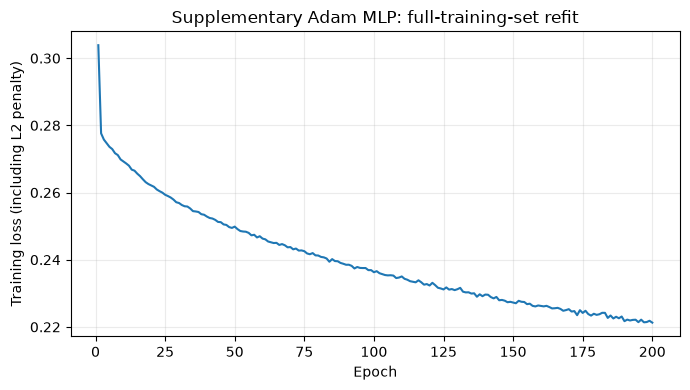

In [97]:
fitted_nn = best_nn.named_steps["model"]
nn_best_train_f1 = nn_results.loc[nn_best_index, "mean_train_f1"]
nn_best_validation_f1 = nn_search.best_score_
nn_f1_gap = nn_best_train_f1 - nn_best_validation_f1

print("Input features after preprocessing:", fitted_nn.n_features_in_)
print("Actual refit epochs:", fitted_nn.n_iter_)
print("Maximum epochs:", fitted_nn.max_iter)
print(f"Final refit training loss: {fitted_nn.loss_:.6f}")
print(f"Mean CV training F1: {nn_best_train_f1:.4f}")
print(f"Mean CV validation F1: {nn_best_validation_f1:.4f}")
print(f"Training minus validation F1: {nn_f1_gap:.4f}")

nn_loss_figure, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(fitted_nn.loss_curve_) + 1), fitted_nn.loss_curve_)
ax.set_xlabel("Epoch")
ax.set_ylabel("Training loss (including L2 penalty)")
ax.set_title("Supplementary Adam MLP: full-training-set refit")
ax.grid(alpha=0.25)
nn_loss_figure.tight_layout()
plt.show()

The selected model's full-training-set refit ran for **200 epochs**.
Its recorded training loss decreased from **0.3039** to
**0.2213**. The refit reached the maximum epoch limit; the limit alone does not demonstrate convergence.

Across validation folds, mean training F1 was **0.5817**, compared
with mean validation F1 of **0.3857**, a difference of
**0.1960**. This substantial gap is consistent with overfitting. The
two-hidden-layer candidates at learning rate 0.001 also achieved high training
F1 (approximately 0.76–0.78) but lower validation F1 (approximately 0.35), showing
that increasing capacity did not improve validation performance in this search.

The grid search (60 cross-validation fits) and final refit recorded 60 convergence warnings. Most fits reached the epoch limit before satisfying the training-loss stopping criterion. These results describe the stated training budget and do not establish that every candidate converged. These warnings indicate an unmet numerical stopping criterion,
not a failed fit. The loss curve was still declining near the epoch limit, but
extending training solely to remove the warnings would not address the observed
training–validation gap. Stronger regularisation or a validation-based comparison
of shorter training schedules would be reasonable follow-up experiments.


### 11.6 Held-out Test Evaluation

After selection by mean validation F1, the refitted pipeline is evaluated once
on the same held-out observations as the classical models. The default prediction
rule is retained. The test scores are descriptive final results and are not used
to change the network, training schedule or decision threshold. The confusion
matrix reports counts of correct and incorrect test predictions.

In [98]:
nn_test_pred = best_nn_pipeline.predict(X_test_rq1)
nn_test_prob = best_nn_pipeline.predict_proba(X_test_rq1)[:, 1]
nn_test_metrics = evaluate_model(y_test, nn_test_pred, nn_test_prob)
display(pd.DataFrame([nn_test_metrics], index=["MLP (Adam; supplementary)"]).round(4))

nn_test_cm = pd.DataFrame(
    confusion_matrix(y_test, nn_test_pred, labels=[0, 1]),
    index=["Actual no (0)", "Actual yes (1)"],
    columns=["Predicted no (0)", "Predicted yes (1)"]
)
display(nn_test_cm)

,Accuracy,Precision,Recall,F1,ROC-AUC
MLP (Adam; supplementary),0.8925,0.5382,0.3265,0.4064,0.7647


,Predicted no (0),Predicted yes (1)
Actual no (0),7048,260
Actual yes (1),625,303


The fixed MLP achieved test F1 **0.4064**, precision
**0.5382**, recall **0.3265**, accuracy
**0.8925** and ROC-AUC **0.7647**. It correctly identified
**303** subscribers and missed **625**, while incorrectly predicting
subscription for **260** non-subscribers. Thus, the model detects some
positive cases but still misses a substantial proportion of subscribers.
These are held-out test measurements, separate from the validation F1 used for
hyperparameter selection.

### 11.7 Findings and Limitations

The selected `(64,)` network is the best of the 12 candidates under the fixed
five-fold split, seed and 200-epoch budget. It is not a global optimum. Most fits
reached the epoch limit, and the training–validation F1 gap indicates overfitting.
The model should therefore be described as the selected network under this
limited search, rather than as fully converged or exhaustively tuned.

Validation scores also guided selection and may be optimistic. Held-out test
results provide a separate assessment of the fixed models. Fold standard
deviations describe variation across validation folds, not uncertainty over
multiple network initialisations. The single random split supports conclusions
about held-out historical observations, rather than future campaigns.

## 12. Supplementary RQ1 Comparison with Adam MLP

All models use the same RQ1 observations and feature definitions. Hyperparameters
are selected by mean validation F1; the table is ordered by that selection metric.
The held-out test metrics describe the resulting fixed models. Zero-R supplies
a common reference for the imbalanced target. Differences from one data split
are descriptive and do not establish statistical significance.

This table includes the supplementary Adam MLP. Section 16.1 gives the primary
comparison with the gradient-descent MLP; their model rankings need not agree.

In [99]:
# Evaluate the majority-class reference on the common held-out test set.
baseline_final = clone(baseline).fit(X_train_rq1, y_train)
baseline_test_metrics = evaluate_model(
    y_test,
    baseline_final.predict(X_test_rq1),
    baseline_final.predict_proba(X_test_rq1)[:, 1]
)

rq1_rows = []
for name, setting, cv_f1, test_metrics in [
    ("Logistic Regression", f"C = {best_lr_C}", best_lr_f1, lr_test_metrics),
    ("Decision Tree", f"max_depth = {best_dt_depth}", best_dt_f1, dt_test_metrics),
    ("SVM", f"C = {best_svm_C}", best_svm_f1, svm_test_metrics),
    ("MLP (Adam; supplementary)",
     f"layers = {best_nn_pipeline.named_steps['model'].hidden_layer_sizes}; "
     f"alpha = {best_nn_pipeline.named_steps['model'].alpha}; "
     f"learning rate = {best_nn_pipeline.named_steps['model'].learning_rate_init}",
     best_nn_f1, nn_test_metrics),
    ("Zero-R", "Most frequent class", baseline_summary.loc["F1", "CV mean"],
     baseline_test_metrics)
]:
    rq1_rows.append({
        "Model": name,
        "Best Hyperparameter": setting,
        "Mean CV F1": cv_f1,
        **{"Test " + metric: value for metric, value in test_metrics.items()}
    })

rq1_results = pd.DataFrame(rq1_rows).sort_values(
    "Mean CV F1", ascending=False, kind="stable"
).reset_index(drop=True)
display(rq1_results.round(4))

,Model,Best Hyperparameter,Mean CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,MLP (Adam; supplementary),"layers = (64,); alpha = 0.0001; learning rate ...",0.3857,0.8925,0.5382,0.3265,0.4064,0.7647
1,Decision Tree,max_depth = 15,0.3735,0.8902,0.5234,0.2888,0.3722,0.6868
2,Logistic Regression,C = 100,0.3447,0.8984,0.6492,0.2134,0.3212,0.8003
3,SVM,C = 0.1,0.3075,0.8952,0.6165,0.1853,0.2850,0.7327
4,Zero-R,Most frequent class,0.0000,0.8873,0.0000,0.0000,0.0000,0.5000


The supplementary Adam MLP has the highest mean validation F1 among the searched model
families (**0.3857**). Its test F1 is
**0.4064**, compared with **0.3722** for
the decision tree, **0.3212** for logistic
regression and **0.2850** for SVM. The supplementary Adam MLP
has the highest observed test F1 (**0.4064**) on this split.

The metrics do not give an identical ranking: Logistic Regression has the highest
test ROC-AUC (**0.8003**). F1 measures the precision–recall
balance at the fixed prediction rule, whereas ROC-AUC evaluates score ranking
across thresholds. High accuracy alone is insufficient, as shown by Zero-R's
test accuracy of **88.73%** and F1 of **0**.
These results answer RQ1 for the selected models on this split; they do not show
that one model is best for every metric or for future campaigns.

## 13. RQ2 Results and Supplementary Adam Comparison

The classical results below reuse the completed RQ2 experiments before Section 11;
they do not rerun tuning or fitting. Section 13.4 adds the supplementary Adam MLP.
The primary gradient-descent MLP comparison appears in Section 16.2.

In [100]:
# Reuse the feature-set definitions already used in the classical RQ2 experiments.
assert set(rq2_sets) == {"Set A", "Set B"}
for data in rq2_sets.values():
    assert data["X_train"].index.equals(y_train.index)
    assert data["X_test"].index.equals(y_test.index)

### 13.1 Logistic Regression

In [101]:
# Reuse previously computed results; no additional model fitting.
for set_name in rq2_sets:
    print("Logistic Regression -", set_name)
    display(lr_rq2_tuning[set_name].round(4))
    print("Best C:", lr_rq2_best[set_name]["C"])
    print("Best CV F1:", round(lr_rq2_best[set_name]["Mean CV F1"], 4))
display(lr_rq2_results_df.round(4))

Logistic Regression - Set A


,C,Mean CV F1,CV F1 SD
0,0.01,0.0,0.0
1,0.10,0.0,0.0
2,1.00,0.0,0.0
3,10.00,0.0,0.0
4,100.00,0.0,0.0
5,1000.00,0.0,0.0


Best C: 0.01
Best CV F1: 0.0
Logistic Regression - Set B


,C,Mean CV F1,CV F1 SD
0,0.01,0.2594,0.0166
1,0.10,0.3004,0.0103
2,1.00,0.3044,0.0102
3,10.00,0.3044,0.0109
4,100.00,0.3048,0.0106
5,1000.00,0.3048,0.0106


Best C: 100
Best CV F1: 0.3048


,Model,Feature Set,Best Parameter,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Set A,C = 0.01,0.0000,0.8873,0.0000,0.0000,0.0000,0.6479
1,Logistic Regression,Set B,C = 100,0.3048,0.8956,0.6241,0.1843,0.2845,0.7014


### 13.2 Decision Tree

In [102]:
# Reuse previously computed results; no additional model fitting.
for set_name in rq2_sets:
    print("Decision Tree -", set_name)
    display(dt_rq2_tuning[set_name].round(4))
    print("Best max_depth:", dt_rq2_best[set_name]["max_depth"])
    print("Best CV F1:", round(dt_rq2_best[set_name]["Mean CV F1"], 4))
display(dt_rq2_results_df.round(4))

Decision Tree - Set A


,max_depth,Mean CV F1,CV F1 SD
0,1,0.0000,0.0000
1,5,0.0476,0.0189
2,10,0.0720,0.0147
3,15,0.1254,0.0081
4,20,0.1340,0.0059
5,None,0.1403,0.0079


Best max_depth: None
Best CV F1: 0.1403
Decision Tree - Set B


,max_depth,Mean CV F1,CV F1 SD
0,1,0.3172,0.0097
1,5,0.2900,0.0124
2,10,0.2950,0.0145
3,15,0.2716,0.0124
4,20,0.2660,0.0101
5,None,0.2598,0.0082


Best max_depth: 1
Best CV F1: 0.3172


,Model,Feature Set,Best Parameter,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,Set A,max_depth = None,0.1403,0.8628,0.2098,0.0787,0.1144,0.5829
1,Decision Tree,Set B,max_depth = 1,0.3172,0.8953,0.6071,0.2015,0.3026,0.5925


### 13.3 SVM

In [103]:
# Reuse previously computed results; no additional model fitting.
for set_name in rq2_sets:
    print("SVM -", set_name)
    display(svm_rq2_tuning[set_name].round(4))
    print("Best C:", svm_rq2_best[set_name]["C"])
    print("Best CV F1:", round(svm_rq2_best[set_name]["Mean CV F1"], 4))
display(svm_rq2_results_df.round(4))

SVM - Set A


,C,Mean CV F1,CV F1 SD
0,0.1,0.0,0.0
1,1.0,0.0,0.0


Best C: 0.1
Best CV F1: 0.0
SVM - Set B


,C,Mean CV F1,CV F1 SD
0,0.1,0.3075,0.0112
1,1.0,0.3075,0.0112


Best C: 0.1
Best CV F1: 0.3075


,Model,Feature Set,Best Parameter,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,SVM,Set A,C = 0.1,0.0000,0.8873,0.0000,0.0000,0.000,0.4952
1,SVM,Set B,C = 0.1,0.3075,0.8952,0.6165,0.1853,0.285,0.6143


### 13.4 Supplementary Adam MLP: Fixed-Configuration Comparison

The neural network uses the RQ1-selected hidden layers, regularisation strength
and learning rate for both feature sets. Batch size, stopping rules, random seed
and prediction rule are also held fixed. Each feature set has its own fitted
preprocessor and network weights. The encoded input dimensions differ because
Set B adds history features; the hidden-layer configuration is unchanged.

Five-fold validation is computed using the shared folds without further tuning.
Each pipeline is then fitted on the full training set and evaluated on the same
test observations. Set B minus Set A measures the change associated with adding
history under this fixed configuration. This is a predictive comparison, not
evidence that previous campaigns causally increase subscription.

In [104]:
# clone removes learned weights while preserving the selected settings.
nn_rq2_model = clone(best_nn_pipeline.named_steps["model"])
nn_rq2_pipelines = {}
nn_rq2_cv_results = {}
nn_rq2_rows = []
nn_rq2_diagnostic_rows = []

for set_name, data in rq2_sets.items():
    assert data["X_train"].index.equals(y_train.index)
    assert data["X_test"].index.equals(y_test.index)
    current_pipeline = make_model_pipeline(data["preprocessor"], nn_rq2_model)

    with warnings.catch_warnings(record=True) as set_warnings:
        warnings.simplefilter("always", ConvergenceWarning)
        with threadpool_limits(limits=1):
            current_cv = cross_validate(
                current_pipeline, data["X_train"], y_train,
                cv=cv_splits, scoring=scoring, return_estimator=True,
                n_jobs=1, error_score="raise"
            )
            current_pipeline.fit(data["X_train"], y_train)

    nn_rq2_pipelines[set_name] = current_pipeline
    nn_rq2_cv_results[set_name] = current_cv
    current_metrics = evaluate_model(
        y_test,
        current_pipeline.predict(data["X_test"]),
        current_pipeline.predict_proba(data["X_test"])[:, 1]
    )
    nn_rq2_rows.append({
        "Model": "MLP (Adam; supplementary)", "Feature Set": set_name,
        "Mean CV F1": current_cv["test_f1"].mean(),
        "CV F1 SD": current_cv["test_f1"].std(ddof=0),
        **current_metrics
    })
    current_model = current_pipeline.named_steps["model"]
    nn_rq2_diagnostic_rows.append({
        "Feature Set": set_name,
        "Input features": current_model.n_features_in_,
        "Refit epochs": current_model.n_iter_,
        "Convergence warnings (5 CV fits + refit)": sum(
            issubclass(w.category, ConvergenceWarning) for w in set_warnings
        )
    })
    print(set_name, "completed")
    for message in sorted({str(w.message) for w in set_warnings}):
        print("Warning:", message)

nn_rq2_results_df = pd.DataFrame(nn_rq2_rows)
nn_rq2_diagnostics = pd.DataFrame(nn_rq2_diagnostic_rows)
display(nn_rq2_results_df.round(4))
display(nn_rq2_diagnostics)

nn_rq2_indexed = nn_rq2_results_df.set_index("Feature Set")
nn_rq2_change = pd.DataFrame({
    "Set B minus Set A":
        nn_rq2_indexed.loc["Set B", list(metric_names.values())]
        - nn_rq2_indexed.loc["Set A", list(metric_names.values())]
})
display(nn_rq2_change.round(4))

Set A completed
Set B completed


,Model,Feature Set,Mean CV F1,CV F1 SD,Accuracy,Precision,Recall,F1,ROC-AUC
0,MLP (Adam; supplementary),Set A,0.0706,0.0244,0.8866,0.4595,0.0366,0.0679,0.6412
1,MLP (Adam; supplementary),Set B,0.2876,0.0165,0.8940,0.5986,0.1800,0.2767,0.6870


,Feature Set,Input features,Refit epochs,Convergence warnings (5 CV fits + refit)
0,Set A,34,157,1
1,Set B,40,193,5


,Set B minus Set A
Accuracy,0.0074
Precision,0.1391
Recall,0.1433
F1,0.2089
ROC-AUC,0.0457


With the same supplementary Adam MLP configuration, mean validation F1 changed from
**0.0706** for Set A to **0.2876** for Set B. Test F1
changed from **0.0679** to **0.2767**, a Set B minus Set A difference
of **+0.2089**. Test recall changed from **0.0366** to
**0.1800**, and ROC-AUC from **0.6412** to **0.6870**.

Both validation and held-out F1 improve with the history features, supporting their additional predictive value under this fixed model configuration.
This comparison changes the feature set while retaining the hidden layers and
training settings. It does not establish a causal effect, and the selected
configuration was not optimised separately for either reduced feature set.

The full-training refits used **157** epochs for Set A
and **193** for Set B. Across the five fold fits and
the full-training refit, Set A recorded **1**
convergence warning and Set B recorded **5** convergence warnings.
The stopping diagnostics limit the interpretation to the stated training budget;
the observed scores do not establish that all fits reached numerical convergence.

### 13.5 RQ2 Results Across Models

The table combines the held-out results using the existing metric names.
The tuning strategy is shown explicitly: the classical models were tuned
separately for each set, while the neural network keeps its RQ1-selected
configuration fixed. Their changes should be interpreted according to these
different experimental designs.

In [105]:
rq2_results = pd.concat([
    lr_rq2_results_df.assign(**{"Tuning Strategy": "Separate search per feature set"}),
    dt_rq2_results_df.assign(**{"Tuning Strategy": "Separate search per feature set"}),
    svm_rq2_results_df.assign(**{"Tuning Strategy": "Separate search per feature set"}),
    nn_rq2_results_df.assign(**{"Tuning Strategy": "Fixed Adam configuration (supplementary)"})
], ignore_index=True)[[
    "Model", "Feature Set", "Tuning Strategy", "Mean CV F1",
    "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"
]]
display(rq2_results.round(4))

,Model,Feature Set,Tuning Strategy,Mean CV F1,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,Set A,Separate search per feature set,0.0000,0.8873,0.0000,0.0000,0.0000,0.6479
1,Logistic Regression,Set B,Separate search per feature set,0.3048,0.8956,0.6241,0.1843,0.2845,0.7014
2,Decision Tree,Set A,Separate search per feature set,0.1403,0.8628,0.2098,0.0787,0.1144,0.5829
3,Decision Tree,Set B,Separate search per feature set,0.3172,0.8953,0.6071,0.2015,0.3026,0.5925
4,SVM,Set A,Separate search per feature set,0.0000,0.8873,0.0000,0.0000,0.0000,0.4952
5,SVM,Set B,Separate search per feature set,0.3075,0.8952,0.6165,0.1853,0.2850,0.6143
6,MLP (Adam; supplementary),Set A,Fixed Adam configuration (supplementary),0.0706,0.8866,0.4595,0.0366,0.0679,0.6412
7,MLP (Adam; supplementary),Set B,Fixed Adam configuration (supplementary),0.2876,0.8940,0.5986,0.1800,0.2767,0.6870


## 14. Supplementary Neural Network References

- Rumelhart, D. E., Hinton, G. E., and Williams, R. J. (1986).
  *Learning representations by back-propagating errors*. Nature, 323, 533–536.
  [https://doi.org/10.1038/323533a0](https://doi.org/10.1038/323533a0).
- Kingma, D. P., and Ba, J. (2015). *Adam: A Method for Stochastic Optimization*.
  International Conference on Learning Representations (ICLR).
  [https://arxiv.org/abs/1412.6980](https://arxiv.org/abs/1412.6980).
- scikit-learn documentation. *MLPClassifier* and *GridSearchCV*.
  [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html);
  [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).

## 15. Primary MLP with Gradient Descent

This primary neural-network experiment uses a small MLP trained by backpropagation and ordinary
gradient descent. Sections 1–14 retain the shared setup and earlier experiments. This model uses
the same features, training/test observations and five validation folds.
Accuracy, precision, recall and positive-class F1 are reported; mean validation F1
selects the configuration. Existing test observations have already been inspected,
so this test comparison is descriptive rather than a fresh confirmation.

### 15.1 Model and Search Settings

One ReLU hidden layer captures nonlinear feature relationships; a sigmoid output
predicts subscription probability. Binary cross-entropy is minimised using
backpropagation (Rumelhart et al., 1986):

$$L=-\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log p_i+(1-y_i)\log(1-p_i)\right],
\qquad \theta\leftarrow\theta-\eta\nabla_\theta L.$$

| Setting | Values |
|---|---|
| Hidden neurons | 16, 32 |
| Constant learning rate | 0.01, 0.1 |
| Batch | All observations in the current fitting partition |
| Maximum epochs | 1,000 |
| Stop rule | Training loss fails to improve by 0.00001 for 20 consecutive epochs |
| Momentum / L2 penalty | Both disabled |
| Seed / prediction rule | 42 / default `predict()` |

The four configurations compare model capacity and update size. Limiting width
is a simple response to the earlier training–validation gap. Each validation fold
fits its own encoder and scaler. The test set does not select parameters.

In [106]:
import warnings
import time
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from threadpoolctl import threadpool_limits

c_metric_names = ["Accuracy", "Precision", "Recall", "F1"]
c_widths = [16, 32]
c_learning_rates = [0.01, 0.1]
c_max_epochs = 1000

assert X_train_rq1.index.equals(y_train.index)
assert X_test_rq1.index.equals(y_test.index)
assert X_train_rq1.index.intersection(X_test_rq1.index).empty
assert "duration" not in X_train_rq1.columns

def c_metrics(y_true, prediction):
    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Recall": recall_score(y_true, prediction, zero_division=0),
        "F1": f1_score(y_true, prediction, zero_division=0),
    }

def c_fit_mlp(preprocessor, X_fit, y_fit, width, rate):
    model = MLPClassifier(
        hidden_layer_sizes=(width,), activation="relu", solver="sgd",
        learning_rate="constant", learning_rate_init=rate,
        batch_size=len(X_fit), momentum=0.0, nesterovs_momentum=False,
        alpha=0.0, max_iter=c_max_epochs, tol=1e-5, n_iter_no_change=20,
        early_stopping=False, shuffle=False, random_state=RANDOM_STATE,
    )
    pipeline = make_model_pipeline(preprocessor, model)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always", ConvergenceWarning)
        with threadpool_limits(limits=1):
            pipeline.fit(X_fit, y_fit)
    messages = [str(w.message) for w in caught
                if issubclass(w.category, ConvergenceWarning)]
    for warning in caught:
        if not issubclass(warning.category, ConvergenceWarning):
            print(warning.category.__name__ + ": " + str(warning.message))
    return pipeline, messages

print("scikit-learn:", sklearn.__version__)
print("Training / test observations:", len(y_train), len(y_test))
print("Candidate configurations:", len(c_widths) * len(c_learning_rates))
print("Validation folds:", len(cv_splits))

scikit-learn: 1.9.1
Training / test observations: 32940 8236
Candidate configurations: 4
Validation folds: 5


### 15.2 Training-set Cross-validation

Each configuration is fitted five times. Training F1 is measured on fitting
observations; validation scores use the corresponding withheld fold. Scores are
averaged across folds. Exact ties retain the first candidate in the listed order.
Warnings and actual epochs are recorded rather than treated as successful convergence.

In [107]:
c_fold_rows = []
c_candidate_models = {}
c_start = time.perf_counter()

for width in c_widths:
    for rate in c_learning_rates:
        c_candidate_models[(width, rate)] = []
        for fold, (fit_pos, val_pos) in enumerate(cv_splits, start=1):
            X_fit = X_train_rq1.iloc[fit_pos]
            X_val = X_train_rq1.iloc[val_pos]
            y_fit = y_train.iloc[fit_pos]
            y_val = y_train.iloc[val_pos]
            pipeline, messages = c_fit_mlp(
                preprocessor_rq1, X_fit, y_fit, width, rate
            )
            model = pipeline.named_steps["model"]
            c_candidate_models[(width, rate)].append(pipeline)
            c_fold_rows.append({
                "Hidden neurons": width, "Learning rate": rate, "Fold": fold,
                "Training F1": f1_score(y_fit, pipeline.predict(X_fit)),
                **c_metrics(y_val, pipeline.predict(X_val)),
                "Epochs": model.n_iter_, "Convergence warnings": len(messages),
            })
            print(f"width={width}, rate={rate}, fold={fold}: "
                  f"F1={c_fold_rows[-1]['F1']:.4f}, epochs={model.n_iter_}, "
                  f"warnings={len(messages)}", flush=True)

c_cv_folds = pd.DataFrame(c_fold_rows)
c_tuning_rows = []
for width in c_widths:
    for rate in c_learning_rates:
        rows = c_cv_folds[
            (c_cv_folds["Hidden neurons"] == width)
            & (c_cv_folds["Learning rate"] == rate)
        ]
        c_tuning_rows.append({
            "Hidden neurons": width, "Learning rate": rate,
            "Training F1": rows["Training F1"].mean(),
            **{"CV " + m: rows[m].mean() for m in c_metric_names},
            "CV F1 SD": rows["F1"].std(ddof=0),
            "Mean epochs": rows["Epochs"].mean(),
            "Convergence warnings": rows["Convergence warnings"].sum(),
        })
c_tuning = pd.DataFrame(c_tuning_rows)
c_selected = c_tuning.loc[c_tuning["CV F1"].idxmax()]
c_best_width = int(c_selected["Hidden neurons"])
c_best_rate = float(c_selected["Learning rate"])
c_best_folds = c_cv_folds[
    (c_cv_folds["Hidden neurons"] == c_best_width)
    & (c_cv_folds["Learning rate"] == c_best_rate)
].copy()
display(c_tuning.sort_values("CV F1", ascending=False, kind="stable").round(4))
display(c_best_folds.round(4))
print(f"Search time: {time.perf_counter() - c_start:.1f} seconds")

width=16, rate=0.01, fold=1: F1=0.2093, epochs=1000, warnings=1
width=16, rate=0.01, fold=2: F1=0.2048, epochs=1000, warnings=1
width=16, rate=0.01, fold=3: F1=0.2090, epochs=1000, warnings=1
width=16, rate=0.01, fold=4: F1=0.1778, epochs=1000, warnings=1
width=16, rate=0.01, fold=5: F1=0.1947, epochs=1000, warnings=1
width=16, rate=0.1, fold=1: F1=0.3508, epochs=571, warnings=0
width=16, rate=0.1, fold=2: F1=0.3135, epochs=562, warnings=0
width=16, rate=0.1, fold=3: F1=0.3343, epochs=580, warnings=0
width=16, rate=0.1, fold=4: F1=0.2952, epochs=563, warnings=0
width=16, rate=0.1, fold=5: F1=0.3310, epochs=557, warnings=0
width=32, rate=0.01, fold=1: F1=0.2348, epochs=1000, warnings=1
width=32, rate=0.01, fold=2: F1=0.2384, epochs=1000, warnings=1
width=32, rate=0.01, fold=3: F1=0.2451, epochs=1000, warnings=1
width=32, rate=0.01, fold=4: F1=0.2167, epochs=1000, warnings=1
width=32, rate=0.01, fold=5: F1=0.2447, epochs=1000, warnings=1
width=32, rate=0.1, fold=1: F1=0.3270, epochs=509,

,Hidden neurons,Learning rate,Training F1,CV Accuracy,CV Precision,CV Recall,CV F1,CV F1 SD,Mean epochs,Convergence warnings
1,16,0.10,0.3279,0.8989,0.6549,0.2164,0.3250,0.0190,566.6,0
3,32,0.10,0.3222,0.8968,0.6253,0.2129,0.3173,0.0077,506.8,0
2,32,0.01,0.2375,0.8953,0.6633,0.1436,0.2359,0.0104,1000.0,5
0,16,0.01,0.1985,0.8939,0.6659,0.1172,0.1991,0.0119,1000.0,5


,Hidden neurons,Learning rate,Fold,Training F1,Accuracy,Precision,Recall,F1,Epochs,Convergence warnings
5,16,0.1,1,0.3230,0.9006,0.6629,0.2385,0.3508,571,0
6,16,0.1,2,0.3254,0.8983,0.6538,0.2062,0.3135,562,0
7,16,0.1,3,0.3336,0.8985,0.6388,0.2264,0.3343,580,0
8,16,0.1,4,0.3315,0.8971,0.6455,0.1914,0.2952,563,0
9,16,0.1,5,0.3259,0.9000,0.6736,0.2194,0.3310,557,0


Search time: 251.3 seconds


In [108]:
c_gap = c_selected["Training F1"] - c_selected["CV F1"]
c_width_summary = c_tuning.groupby("Hidden neurons")[["Training F1", "CV F1"]].max()
display(c_width_summary.round(4).rename(columns={
    "Training F1": "Highest training F1 across learning rates",
    "CV F1": "Highest validation F1 across learning rates"
}))
display(Markdown(
    f"The selected network has **{c_best_width} hidden neurons** and learning rate "
    f"**{c_best_rate}**. Mean validation F1 is **{c_selected['CV F1']:.4f}** "
    f"(SD {c_selected['CV F1 SD']:.4f}), compared with Zero-R's F1 of 0. "
    f"Training F1 is {c_selected['Training F1']:.4f}, giving a training-minus-validation "
    f"gap of {c_gap:.4f}. The scores describe this candidate grid and fixed split; "
    f"they do not establish a globally best architecture."
))

,Highest training F1 across learning rates,Highest validation F1 across learning rates
Hidden neurons,,
16,0.3279,0.3250
32,0.3222,0.3173


The selected network has **16 hidden neurons** and learning rate **0.1**. Mean validation F1 is **0.3250** (SD 0.0190), compared with Zero-R's F1 of 0. Training F1 is 0.3279, giving a training-minus-validation gap of 0.0029. The scores describe this candidate grid and fixed split; they do not establish a globally best architecture.

### 15.3 Refit and Training Diagnostics

The selected settings are refitted on all training observations. The loss curve
shows optimisation progress. Training versus validation F1 shows how performance
changes outside the fitting data; a decreasing training loss alone cannot exclude
overfitting. Reaching the epoch limit is reported explicitly.

,Experiment,Input features,Epochs,Initial loss,Final loss,CV convergence warnings,Refit convergence warnings
0,RQ1,63,554,0.599,0.28126,0,0


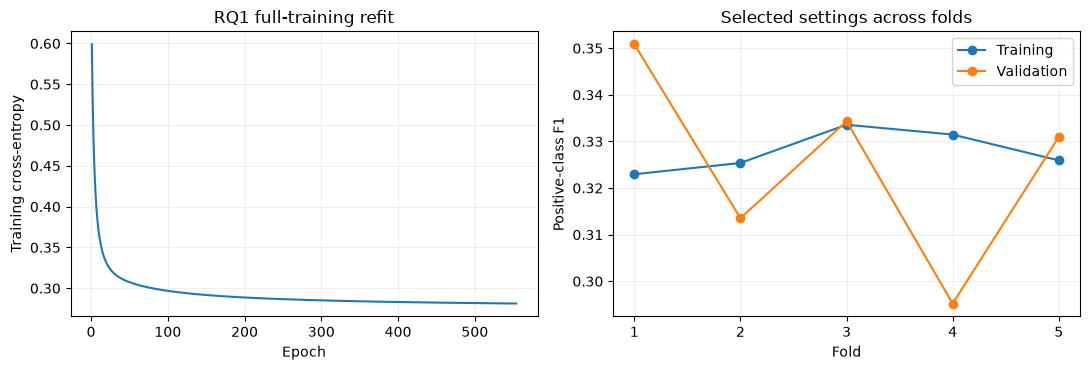

Training loss changed from 0.5990 to 0.2813 over 554 epochs. The refit met the configured loss-based stopping criterion; this does not guarantee a global optimum. 10 of the 20 search fits reported a convergence warning. These diagnostics limit claims about optimisation.

In [109]:
c_rq1_model, c_refit_warnings = c_fit_mlp(
    preprocessor_rq1, X_train_rq1, y_train, c_best_width, c_best_rate
)
c_fitted = c_rq1_model.named_steps["model"]
c_diagnostics = pd.DataFrame([{
    "Experiment": "RQ1", "Input features": c_fitted.n_features_in_,
    "Epochs": c_fitted.n_iter_, "Initial loss": c_fitted.loss_curve_[0],
    "Final loss": c_fitted.loss_curve_[-1],
    "CV convergence warnings": int(c_best_folds["Convergence warnings"].sum()),
    "Refit convergence warnings": len(c_refit_warnings),
}])
display(c_diagnostics.round(5))
for message in sorted(set(c_refit_warnings)):
    print("ConvergenceWarning:", message)

c_training_figure, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(range(1, c_fitted.n_iter_ + 1), c_fitted.loss_curve_)
axes[0].set(xlabel="Epoch", ylabel="Training cross-entropy", title="RQ1 full-training refit")
axes[1].plot(c_best_folds["Fold"], c_best_folds["Training F1"], "o-", label="Training")
axes[1].plot(c_best_folds["Fold"], c_best_folds["F1"], "o-", label="Validation")
axes[1].set(xlabel="Fold", ylabel="Positive-class F1", title="Selected settings across folds")
axes[1].set_xticks(range(1, len(cv_splits) + 1))
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.2)
c_training_figure.tight_layout()
plt.show()

c_stop_note = ("The refit reached the epoch limit and did not meet the loss-based "
               "stopping criterion." if c_refit_warnings else
               "The refit met the configured loss-based stopping criterion; this "
               "does not guarantee a global optimum.")
display(Markdown(
    f"Training loss changed from {c_fitted.loss_curve_[0]:.4f} to "
    f"{c_fitted.loss_curve_[-1]:.4f} over {c_fitted.n_iter_} epochs. {c_stop_note} "
    f"{int(c_cv_folds['Convergence warnings'].sum())} of the 20 search fits "
    "reported a convergence warning. These diagnostics limit claims about optimisation."
))

## 16. Primary Neural-network Experiments

### 16.1 RQ1: Comparison on the Common Test Observations

The gradient-descent MLP is compared with the three classical models and Zero-R
using identical RQ1 test rows. The table is ordered by mean validation F1, the
selection criterion. Test precision and recall show the balance between false
alarms and missed subscribers; accuracy provides the majority-class reference.

In [110]:
c_rq1_prediction = c_rq1_model.predict(X_test_rq1)
c_rq1_metrics = c_metrics(y_test, c_rq1_prediction)
c_baseline = DummyClassifier(strategy="most_frequent").fit(X_train_rq1, y_train)
c_baseline_metrics = c_metrics(y_test, c_baseline.predict(X_test_rq1))
c_rq1_rows = []
for name, cv_f1, values in [
    ("Logistic Regression", best_lr_f1, lr_test_metrics),
    ("Decision Tree", best_dt_f1, dt_test_metrics),
    ("Linear SVM", best_svm_f1, svm_test_metrics),
    ("MLP (gradient descent)", c_selected["CV F1"], c_rq1_metrics),
    ("Zero-R", 0.0, c_baseline_metrics),
]:
    c_rq1_rows.append({"Model": name, "Mean CV F1": cv_f1,
                       **{"Test " + m: values[m] for m in c_metric_names}})
c_rq1_comparison = pd.DataFrame(c_rq1_rows).sort_values(
    "Mean CV F1", ascending=False, kind="stable"
).reset_index(drop=True)
display(c_rq1_comparison.round(4))

c_rq1_cm = confusion_matrix(y_test, c_rq1_prediction, labels=[0, 1])
display(pd.DataFrame(c_rq1_cm, index=["Actual no", "Actual yes"],
                     columns=["Predicted no", "Predicted yes"]))
c_tn, c_fp, c_fn, c_tp = c_rq1_cm.ravel()
display(Markdown(
    f"The MLP obtains test F1 **{c_rq1_metrics['F1']:.4f}**, precision "
    f"{c_rq1_metrics['Precision']:.4f} and recall {c_rq1_metrics['Recall']:.4f}. "
    f"It identifies {c_tp} of {c_tp + c_fn} subscribers, misses {c_fn}, and "
    f"incorrectly flags {c_fp} non-subscribers. Zero-R misses every subscriber. "
    f"The highest mean validation F1 in this table belongs to "
    f"**{c_rq1_comparison.iloc[0]['Model']}**; test differences on this split "
    "alone do not establish consistent superiority."
))

,Model,Mean CV F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Decision Tree,0.3735,0.8902,0.5234,0.2888,0.3722
1,Logistic Regression,0.3447,0.8984,0.6492,0.2134,0.3212
2,MLP (gradient descent),0.3250,0.8983,0.6531,0.2069,0.3142
3,Linear SVM,0.3075,0.8952,0.6165,0.1853,0.2850
4,Zero-R,0.0000,0.8873,0.0000,0.0000,0.0000


,Predicted no,Predicted yes
Actual no,7206,102
Actual yes,736,192


The MLP obtains test F1 **0.3142**, precision 0.6531 and recall 0.2069. It identifies 192 of 928 subscribers, misses 736, and incorrectly flags 102 non-subscribers. Zero-R misses every subscriber. The highest mean validation F1 in this table belongs to **Decision Tree**; test differences on this split alone do not establish consistent superiority.

### 16.2 RQ2: Added Value of Previous Campaign History

The selected hidden width and learning rate are fixed for both feature sets.
Set A contains demographic/financial information; Set B adds the four history
features from Section 6. Each model is trained separately, using the same folds,
stopping rule and prediction rule. Input width and learned weights necessarily
differ. The comparison measures predictive value, not a causal effect of contact.

In [111]:
c_rq2_sets = {
    "Set A": (X_train_without, X_test_without, preprocessor_without),
    "Set B": (X_train_with, X_test_with, preprocessor_with),
}
c_rq2_models = {}
c_rq2_predictions = {}
c_rq2_fold_rows = []
c_rq2_rows = []
c_rq2_diagnostic_rows = []

for set_name, (X_train_set, X_test_set, preprocessor) in c_rq2_sets.items():
    assert X_train_set.index.equals(y_train.index)
    assert X_test_set.index.equals(y_test.index)
    for fold, (fit_pos, val_pos) in enumerate(cv_splits, start=1):
        pipeline, messages = c_fit_mlp(
            preprocessor, X_train_set.iloc[fit_pos], y_train.iloc[fit_pos],
            c_best_width, c_best_rate
        )
        c_rq2_fold_rows.append({
            "Feature set": set_name, "Fold": fold,
            **c_metrics(y_train.iloc[val_pos], pipeline.predict(X_train_set.iloc[val_pos])),
            "Training F1": f1_score(y_train.iloc[fit_pos], pipeline.predict(X_train_set.iloc[fit_pos])),
            "Epochs": pipeline.named_steps["model"].n_iter_,
            "Convergence warnings": len(messages),
        })
        print(f"{set_name}, fold={fold}: F1={c_rq2_fold_rows[-1]['F1']:.4f}, "
              f"warnings={len(messages)}", flush=True)

    pipeline, messages = c_fit_mlp(
        preprocessor, X_train_set, y_train, c_best_width, c_best_rate
    )
    c_rq2_models[set_name] = pipeline
    prediction = pipeline.predict(X_test_set)
    c_rq2_predictions[set_name] = prediction
    rows = pd.DataFrame([r for r in c_rq2_fold_rows if r["Feature set"] == set_name])
    c_rq2_rows.append({
        "Feature set": set_name,
        "CV F1": rows["F1"].mean(), "CV F1 SD": rows["F1"].std(ddof=0),
        "Training F1": rows["Training F1"].mean(),
        **{"Test " + k: v for k, v in c_metrics(y_test, prediction).items()},
    })
    model = pipeline.named_steps["model"]
    c_rq2_diagnostic_rows.append({
        "Feature set": set_name, "Input features": model.n_features_in_,
        "Refit epochs": model.n_iter_,
        "CV convergence warnings": rows["Convergence warnings"].sum(),
        "Refit convergence warnings": len(messages),
    })
    for message in sorted(set(messages)):
        print(set_name, "ConvergenceWarning:", message)

c_rq2_folds = pd.DataFrame(c_rq2_fold_rows)
c_rq2_results = pd.DataFrame(c_rq2_rows).set_index("Feature set")
c_rq2_diagnostics = pd.DataFrame(c_rq2_diagnostic_rows)
display(c_rq2_results.round(4))
display(c_rq2_diagnostics)
c_rq2_delta = c_rq2_results.loc["Set B"] - c_rq2_results.loc["Set A"]
display(c_rq2_delta[["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]]
        .rename("Set B minus Set A").to_frame().round(4))
c_rq2_paired = c_rq2_folds.pivot(index="Fold", columns="Feature set", values="F1")
c_rq2_paired["B minus A"] = c_rq2_paired["Set B"] - c_rq2_paired["Set A"]
display(c_rq2_paired.round(4))
display(Markdown(
    f"Adding history changes test F1 from **{c_rq2_results.loc['Set A', 'Test F1']:.4f}** "
    f"to **{c_rq2_results.loc['Set B', 'Test F1']:.4f}** "
    f"(difference {c_rq2_delta['Test F1']:+.4f}). Mean validation F1 changes by "
    f"{c_rq2_delta['CV F1']:+.4f}, and Set B scores higher in "
    f"{int((c_rq2_paired['B minus A'] > 0).sum())} of five folds. "
    f"Test recall changes by {c_rq2_delta['Test Recall']:+.4f}. "
    "The result is conditional on the fixed configuration; it does not compare "
    "independently optimised feature sets or establish causality."
))

Set A, fold=1: F1=0.0212, warnings=0
Set A, fold=2: F1=0.0027, warnings=0
Set A, fold=3: F1=0.0159, warnings=0
Set A, fold=4: F1=0.0054, warnings=0
Set A, fold=5: F1=0.0159, warnings=0
Set B, fold=1: F1=0.3015, warnings=0
Set B, fold=2: F1=0.2770, warnings=0
Set B, fold=3: F1=0.2658, warnings=0
Set B, fold=4: F1=0.2826, warnings=0
Set B, fold=5: F1=0.2544, warnings=0


,CV F1,CV F1 SD,Training F1,Test Accuracy,Test Precision,Test Recall,Test F1
Feature set,,,,,,,
Set A,0.0122,0.0070,0.0118,0.8872,0.4444,0.0043,0.0085
Set B,0.2763,0.0159,0.2778,0.8944,0.6169,0.1649,0.2602


,Feature set,Input features,Refit epochs,CV convergence warnings,Refit convergence warnings
0,Set A,34,576,0,0
1,Set B,40,639,0,0


,Set B minus Set A
CV F1,0.2641
Test Accuracy,0.0072
Test Precision,0.1725
Test Recall,0.1606
Test F1,0.2517


Feature set,Set A,Set B,B minus A
Fold,,,
1,0.0212,0.3015,0.2803
2,0.0027,0.2770,0.2743
3,0.0159,0.2658,0.2499
4,0.0054,0.2826,0.2772
5,0.0159,0.2544,0.2385


Adding history changes test F1 from **0.0085** to **0.2602** (difference +0.2517). Mean validation F1 changes by +0.2641, and Set B scores higher in 5 of five folds. Test recall changes by +0.1606. The result is conditional on the fixed configuration; it does not compare independently optimised feature sets or establish causality.

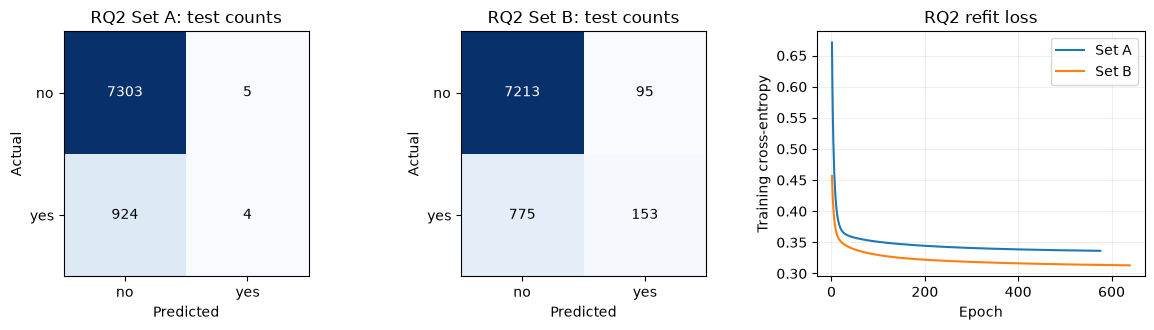

In [112]:
c_history_figure, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, set_name in zip(axes[:2], ["Set A", "Set B"]):
    cm = confusion_matrix(y_test, c_rq2_predictions[set_name], labels=[0, 1])
    ax.imshow(cm, cmap="Blues")
    for row in range(2):
        for col in range(2):
            ax.text(col, row, str(cm[row, col]), ha="center", va="center",
                    color="white" if cm[row, col] > cm.max() / 2 else "black")
    ax.set(xticks=[0, 1], yticks=[0, 1], xticklabels=["no", "yes"],
           yticklabels=["no", "yes"], xlabel="Predicted", ylabel="Actual",
           title=f"RQ2 {set_name}: test counts")
for set_name, pipeline in c_rq2_models.items():
    losses = pipeline.named_steps["model"].loss_curve_
    axes[2].plot(range(1, len(losses) + 1), losses, label=set_name)
axes[2].set(xlabel="Epoch", ylabel="Training cross-entropy", title="RQ2 refit loss")
axes[2].legend()
axes[2].grid(alpha=0.2)
c_history_figure.tight_layout()
plt.show()

### 16.3 Error Analysis

The following examples are the first two false negatives and false positives in
test-row order, rather than hand-picked cases. Actual and predicted labels are
shown beside available features. The group table checks whether adding history
changes recall across prior campaign outcomes; group counts matter when interpreting
small subgroups. These test observations are not used for further tuning.

In [113]:
c_error_cases = X_test_rq1[["age", "job", "education", "previous", "poutcome"]].copy()
c_error_cases["Actual"] = y_test
c_error_cases["Predicted"] = c_rq1_prediction
c_error_cases["P(yes)"] = c_rq1_model.predict_proba(X_test_rq1)[:, 1]
c_error_cases["Error"] = np.select(
    [(c_error_cases["Actual"] == 1) & (c_error_cases["Predicted"] == 0),
     (c_error_cases["Actual"] == 0) & (c_error_cases["Predicted"] == 1)],
    ["False negative", "False positive"], default="Correct"
)
c_examples = pd.concat([
    c_error_cases[c_error_cases["Error"] == label].head(2)
    for label in ["False negative", "False positive"]
])
display(c_examples.round(4))

c_group_rows = []
for outcome in sorted(X_test_with["poutcome"].unique()):
    mask = X_test_with["poutcome"].eq(outcome).to_numpy()
    actual = y_test.to_numpy()[mask]
    positives = int(actual.sum())
    a_pred = c_rq2_predictions["Set A"][mask]
    b_pred = c_rq2_predictions["Set B"][mask]
    c_group_rows.append({
        "Previous outcome": outcome, "Test observations": int(mask.sum()),
        "Actual subscribers": positives,
        "Set A recall": recall_score(actual, a_pred, zero_division=0) if positives else np.nan,
        "Set B recall": recall_score(actual, b_pred, zero_division=0) if positives else np.nan,
        "Set A false positives": int(((actual == 0) & (a_pred == 1)).sum()),
        "Set B false positives": int(((actual == 0) & (b_pred == 1)).sum()),
    })
c_history_groups = pd.DataFrame(c_group_rows)
display(c_history_groups.round(4))

# Explain one concrete error and, when present, a subscriber recovered by history.
c_fn_examples = c_error_cases[c_error_cases["Error"] == "False negative"]
if not c_fn_examples.empty:
    row_id = c_fn_examples.index[0]
    example = c_fn_examples.iloc[0]
    outcome = example["poutcome"]
    train_mask = X_train_rq1["poutcome"].eq(outcome)
    group_rate = y_train.loc[train_mask].mean()
    display(Markdown(
        f"Test row **{row_id}** is a subscriber but receives P(yes)="
        f"{example['P(yes)']:.4f}, below the default 0.5 decision boundary. "
        f"Its previous outcome is **{outcome}**. In the training data, "
        f"{group_rate:.1%} of records with that outcome are subscribers. "
        "This illustrates a missed minority-class case; the group frequency "
        "describes context and does not prove which feature caused this prediction."
    ))

c_recovered = ((y_test.to_numpy() == 1)
               & (c_rq2_predictions["Set A"] == 0)
               & (c_rq2_predictions["Set B"] == 1))
if c_recovered.any():
    position = int(np.flatnonzero(c_recovered)[0])
    row_id = y_test.index[position]
    prob_a = c_rq2_models["Set A"].predict_proba(X_test_without.iloc[[position]])[0, 1]
    prob_b = c_rq2_models["Set B"].predict_proba(X_test_with.iloc[[position]])[0, 1]
    outcome = X_test_with.iloc[position]["poutcome"]
    display(Markdown(
        f"For RQ2, subscriber **{row_id}** is missed by Set A "
        f"(P(yes)={prob_a:.4f}) and correctly identified by Set B "
        f"(P(yes)={prob_b:.4f}); the previous outcome is **{outcome}**. "
        "The added history features allow a different decision for this case, "
        "although the comparison does not attribute it to one history feature alone."
    ))
else:
    display(Markdown("No test subscriber missed by Set A is recovered by Set B "
                     "under this configuration."))


,age,job,education,previous,poutcome,Actual,Predicted,P(yes),Error
2443,31,services,basic.6y,0,nonexistent,1,0,0.0244,False negative
16346,31,blue-collar,unknown,0,nonexistent,1,0,0.0471,False negative
38275,36,admin.,university.degree,2,success,0,1,0.6814,False positive
37466,34,housemaid,university.degree,1,success,0,1,0.5711,False positive


,Previous outcome,Test observations,Actual subscribers,Set A recall,Set B recall,Set A false positives,Set B false positives
0,failure,837,127,0.0079,0.1024,1,13
1,nonexistent,7120,629,0.0048,0.0000,4,0
2,success,279,172,0.0000,0.8140,0,82


Test row **2443** is a subscriber but receives P(yes)=0.0244, below the default 0.5 decision boundary. Its previous outcome is **nonexistent**. In the training data, 8.8% of records with that outcome are subscribers. This illustrates a missed minority-class case; the group frequency describes context and does not prove which feature caused this prediction.

For RQ2, subscriber **40832** is missed by Set A (P(yes)=0.1933) and correctly identified by Set B (P(yes)=0.5624); the previous outcome is **success**. The added history features allow a different decision for this case, although the comparison does not attribute it to one history feature alone.

## 17. Primary Findings and Limitations

The validation and test tables answer RQ1 under the shared split and identify the
precision–recall trade-off. The fixed-configuration Set A/Set B experiment answers
RQ2 by measuring the additional predictive information in campaign history.
The selected model is discussed below using the observed errors and validation gap.

In [114]:
c_recall_gain = c_history_groups["Set B recall"] - c_history_groups["Set A recall"]
c_largest_group = c_history_groups.loc[c_recall_gain.idxmax()]
c_capacity_best = c_tuning.groupby("Hidden neurons")["CV F1"].max()
c_capacity_change = c_capacity_best.loc[32] - c_capacity_best.loc[16]
display(Markdown(
    f"Increasing hidden width from 16 to 32 changes the best validation F1 across "
    f"the two learning rates by {c_capacity_change:+.4f}. This illustrates that "
    "extra capacity must be assessed on validation data. "
    f"The selected model's training–validation F1 gap is {c_gap:.4f}; "
    f"the validation-fold SD is {c_selected['CV F1 SD']:.4f}. "
    "A small gap is not evidence of severe overfitting. The limited recall and "
    "the classical-model comparison still matter when judging usefulness."
))
display(Markdown(
    f"For RQ2, the largest observed recall increase is in the "
    f"**{c_largest_group['Previous outcome']}** group "
    f"({int(c_largest_group['Actual subscribers'])} actual subscribers): "
    f"{c_largest_group['Set A recall']:.4f} to {c_largest_group['Set B recall']:.4f}. "
    "This suggests that prior outcomes help distinguish some subscribers who "
    "are difficult to identify from demographic and financial variables alone. "
    "The group comparison is descriptive and does not isolate a single feature's effect."
))

c_smallest_group = c_history_groups.loc[c_recall_gain.idxmin()]
display(Markdown(
    f"The benefit is uneven: the **{c_smallest_group['Previous outcome']}** group "
    f"has {int(c_smallest_group['Actual subscribers'])} subscribers, and recall "
    f"changes from {c_smallest_group['Set A recall']:.4f} to "
    f"{c_smallest_group['Set B recall']:.4f}. Overall improvement therefore does "
    "not mean improved detection in every history group."
))


Increasing hidden width from 16 to 32 changes the best validation F1 across the two learning rates by -0.0076. This illustrates that extra capacity must be assessed on validation data. The selected model's training–validation F1 gap is 0.0029; the validation-fold SD is 0.0190. A small gap is not evidence of severe overfitting. The limited recall and the classical-model comparison still matter when judging usefulness.

For RQ2, the largest observed recall increase is in the **success** group (172 actual subscribers): 0.0000 to 0.8140. This suggests that prior outcomes help distinguish some subscribers who are difficult to identify from demographic and financial variables alone. The group comparison is descriptive and does not isolate a single feature's effect.

The benefit is uneven: the **nonexistent** group has 629 subscribers, and recall changes from 0.0048 to 0.0000. Overall improvement therefore does not mean improved detection in every history group.

The experiment uses one random stratified split and one initialisation seed.
The source data are time ordered, so this design measures performance on a mixed-period
sample rather than future campaigns. Previously inspected test data, a limited
parameter grid and any convergence warnings further restrict the conclusions.
RQ2 controls hidden width and training rules, but adding inputs also changes the
number of weights. The classical RQ2 models in Section 13 use separate tuning per
feature set, so their changes answer a different configuration-selection question.

### 17.1 Related Work and Sources

Moro et al. (2014) study bank telemarketing prediction and motivate this dataset and
task; their published results are not directly comparable to this feature definition
and split. Rumelhart et al. (1986) provide the backpropagation learning method.
Hornik et al. (1989) establish approximation results under squashing-activation
assumptions. This motivates separating representational capacity from empirical
performance; it does not prove optimality for the finite ReLU networks used here.

- Moro, S., Cortez, P., and Rita, P. (2014). *A data-driven approach to predict the
  success of bank telemarketing*. Decision Support Systems, 62, 22–31.
  https://doi.org/10.1016/j.dss.2014.03.001
- Rumelhart, D. E., Hinton, G. E., and Williams, R. J. (1986).
  *Learning representations by back-propagating errors*. Nature, 323, 533–536.
  https://doi.org/10.1038/323533a0
- Hornik, K., Stinchcombe, M., and White, H. (1989). *Multilayer feedforward networks
  are universal approximators*. Neural Networks, 2(5), 359–366.
  https://doi.org/10.1016/0893-6080(89)90020-8
- Data: UCI Bank Marketing, `bank-additional-full.csv`, 41,188 rows before duplicate
  removal. https://archive.ics.uci.edu/dataset/222/bank+marketing
- Implementation: scikit-learn `MLPClassifier` documentation.
  https://scikit-learn.org/1.8/modules/generated/sklearn.neural_network.MLPClassifier.html